# Boat model explorer

A working model of the boat from `optimization2.md`, for poking at. Change an input, re-run, and see what
moves. Units are imperial (ft, in, lb, mph, Wh) because that is how the design is discussed.

**Full write-up:** every decision variable, calculated value, constraint and the objective of this model are documented in a LaTeX overview: [read the PDF](https://github.com/MarMar888/hav/blob/master/optimization/explore-model.pdf) ([LaTeX source](https://github.com/MarMar888/hav/blob/master/optimization/explore-model.tex)).

**What is real and what is not**

| Piece | Status |
| --- | --- |
| Planing equilibrium (trim, wetted length, thrust needed) | Real: [OpenPlaning](https://github.com/elcf/python-openplaning), Savitsky's empirical method. Prismatic hull only. |
| Hydrostatics, freeboard, hull mass | Ours, closed form for a prismatic V-hull. The **prismatic coefficient is a guess**. |
| Propeller rpm, tip speed, Kv | Your equation: `rpm = mph x 1056 / (pitch x 0.85)`, `Kv = rpm / loaded voltage`. |
| Battery voltage under load | Ours: `V = (Voc + sqrt(Voc^2 - 4 R P)) / 2`. |
| Cell data, motor mass fit, propeller efficiency, current limit | **Placeholders**. Every one is marked `PLACEHOLDER` below. |

Nothing here is validated against a real boat. Use it to learn which variables matter and where the
constraints bite, not to read off a design.

**Version:** the first code cell prints the model version (`optimization/VERSION`, plus the git commit and whether
there are uncommitted edits). Check it before trusting a saved chart; see `docs/VERSIONING.md`.

**Run it:** `optimization/.venv/bin/jupyter lab optimization/explore.ipynb`, then Run All. The optimizer
cell near the end takes about a minute.

## 1. Setup

In [65]:
import math, subprocess, time, warnings
from pathlib import Path
from dataclasses import dataclass, field, replace

warnings.filterwarnings("ignore", message="pkg_resources")   # OpenPlaning imports it; harmless

import numpy as np


import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from openplaning import PlaningBoat

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

# unit conversions to SI (OpenPlaning works in SI)
LB_N, IN, FT, MPH = 4.44822162, 0.0254, 0.3048, 0.44704
LB_FT3_TO_KG_M3 = 16.01846


def model_version():
    """Version from optimization/VERSION (see docs/VERSIONING.md), plus the git commit and whether the tree has edits."""
    here = Path.cwd()
    root = next((p for p in (here, *here.parents) if (p / "optimization" / "VERSION").exists()
                 or (p.name == "optimization" and (p / "VERSION").exists())), None)
    if root is None: return "optimization (VERSION file not found)"
    ver = (root / "VERSION" if root.name == "optimization" else root / "optimization" / "VERSION").read_text().strip()
    try:
        git = lambda *a: subprocess.run(["git", "-C", str(root), *a], capture_output=True, text=True, check=True).stdout.strip()
        commit = git("rev-parse", "--short", "HEAD")
        dirty = bool(git("status", "--porcelain", "--", str(root)))
        return f"optimization v{ver} ({commit}{', with uncommitted changes' if dirty else ''})"
    except (OSError, subprocess.CalledProcessError):
        return f"optimization v{ver}"


MODEL_VERSION = model_version()
print("Boat model explorer:", MODEL_VERSION)

Boat model explorer: optimization v0.1.3 (3e7c545, with uncommitted changes)


## 2. Inputs

Two groups. `Design` holds the decision variables the optimizer would choose. `Fixed` holds everything held
constant: rules, environment, and placeholder assumptions. Edit the defaults here or override them in later
cells with `replace(design, beam_in=20)`.

In [66]:
@dataclass
class Cell:
    # PLACEHOLDER numbers for a generic high-drain 21700 cell. Not from a datasheet.
    ah: float = 5.0
    v_nominal: float = 3.6
    v_full: float = 4.2
    resistance_ohm: float = 0.015
    mass_lb: float = 0.154
    max_current_a: float = 15.0          # continuous, per cell
    soc: tuple = (0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 1.0)
    ocv: tuple = (3.00, 3.45, 3.55, 3.65, 3.75, 3.92, 4.00, 4.10, 4.20)   # generic NMC curve
    pack_overhead: float = 0.15          # case, BMS, wiring as a fraction of cell mass

# THESE ARE THE ASSUMPTIONS AND CONSTANTS FOR THE MODEL
@dataclass
class Fixed:
    # rules
    payload_lb: float = 30.0
    freeboard_rule_in: float = 3.0
    voltage_limit_v: float = 55.5
    # environment (wave height and current are TO BE SET)
    water_lb_ft3: float = 62.4                # fresh
    water_nu: float = 1.14e-6                 # kinematic viscosity, m^2/s
    wave_height_in: float = 4.0
    wave_allowance_factor: float = 0.5        # freeboard must cover H/2 on top of the rule
    current_mph: float = 1.0
    course_mode: str = "worst"                # "worst": whole course against the current; "outback": equal legs
    # mission
    course_miles: float = 2.0
    allowance_s: float = 20.0
    hotel_w: float = 30.0
    # design margins
    usable_energy_fraction: float = 0.70      # of the energy in the pack at the start of the race
    rating_fraction: float = 0.80
    lcg_band: tuple = (0.30, 0.45)            # fraction of length from the transom
    min_cell_voltage_end: float = 3.0
    # hull construction (synthetic)
    laminate_lb_ft2: float = 0.41
    hull_structure_lb: float = 4.4
    fixed_equipment_lb: float = 8.8
    prismatic_coeff: float = 0.85             # PLACEHOLDER: a pure prism overstates static volume
    # heights above the keel (in) and radius of gyration for the mass model; all PLACEHOLDER
    payload_z_in: float = 8.0
    battery_z_in: float = 4.0
    motor_z_in: float = 4.0
    fixed_z_in: float = 8.0
    hull_z_frac_of_depth: float = 0.45
    gyradius_frac: float = 0.25               # of length
    thrust_height_in: float = 4.0
    # propulsion (PLACEHOLDER)
    prop_efficiency: float = 0.65             # no propeller model yet, so pitch and diameter do not change this
    prop_mass_lb: float = 0.5
    motor_max_voltage_v: float = 60.0
    slip_factor: float = 0.85                 # your rpm equation
    cell: Cell = field(default_factory=Cell)

# THIS IS AN EXAMPLE DESIGN CONFIGURATION -- if we want to run a sim against something else, we can do it here, it does not impact outcome of model.
@dataclass
class Design:
    # hull (prismatic)
    length_ft: float = 8.5
    beam_in: float = 16.0
    deadrise_deg: float = 10.0
    depth_in: float = 12.0
    # propulsion
    motor_kw: float = 4.0
    motor_eff: float = 0.90
    pitch_in: float = 10.0
    prop_diam_in: float = 6.0
    thrust_angle_deg: float = 0.0
    # battery
    series: int = 14
    parallel: int = 6
    # placement (fraction of length forward of the transom)
    payload_x: float = 0.30
    battery_x: float = 0.35
    # operation
    speed_mph: float = 22.0


FIXED, DESIGN = Fixed(), Design()

## 3. Hull: prismatic hydrostatics and mass

V-bottom section of chine beam `b` and deadrise `beta`, vertical sides up to the hull depth, the same from transom to
bow. The chine sits `b/2 * tan(beta)` above the keel. Static volume is `prismatic coefficient x section area x
length`. Freeboard is measured at rest, which is conservative because the boat rides higher when planing.

In [67]:
def chine_height_ft(d):
    return d.beam_in / 12 / 2 * math.tan(math.radians(d.deadrise_deg))


def section_area_ft2(draft_ft, d):
    b, t = d.beam_in / 12, math.tan(math.radians(d.deadrise_deg))
    hc = b / 2 * t
    return draft_ft ** 2 / t if draft_ft <= hc else b * hc / 2 + b * (draft_ft - hc)


def static_draft_ft(mass_lb, d, f):
    # invert section_area_ft2 for the draft that floats the boat
    area = (mass_lb / f.water_lb_ft3) / (f.prismatic_coeff * d.length_ft)
    b, t = d.beam_in / 12, math.tan(math.radians(d.deadrise_deg))
    hc = b / 2 * t
    a_chine = b * hc / 2
    return math.sqrt(area * t) if area <= a_chine else hc + (area - a_chine) / b


def shell_area_ft2(d):
    b, L, D = d.beam_in / 12, d.length_ft, d.depth_in / 12
    hc = chine_height_ft(d)
    side_h = max(D - hc, 0.0)
    bottom = b * L / math.cos(math.radians(d.deadrise_deg))
    return bottom + 2 * side_h * L + b * L + b * side_h + b * hc / 2   # bottom, sides, deck, transom


def hull_mass_lb(d, f):
    return shell_area_ft2(d) * f.laminate_lb_ft2 + f.hull_structure_lb

## 4. Battery

`capacity = S x P x cell Ah x cell nominal volts`. The start-of-race charge is **derived**: the highest charge at which the
open-circuit voltage stays at or under the 55.5 V rule (capped at 100%). Under load the voltage sags by the pack's internal
resistance: solving `V = Voc - I R` with `I = P / V` gives `V = (Voc + sqrt(Voc^2 - 4 R P)) / 2`, which only has a solution
while `Voc^2 >= 4 R P`.

In [68]:
def ocv(soc, cell):
    return float(np.interp(soc, cell.soc, cell.ocv))


def start_soc(series, f):
    cell = f.cell
    if series * cell.v_full <= f.voltage_limit_v:
        return 1.0
    return float(np.interp(f.voltage_limit_v / series, cell.ocv, cell.soc))


def pack(d, f):
    c = f.cell
    n = d.series * d.parallel
    return dict(cells=n, capacity_wh=n * c.ah * c.v_nominal,
                mass_lb=n * c.mass_lb * (1 + c.pack_overhead),
                resistance_ohm=d.series / d.parallel * c.resistance_ohm,
                current_limit_a=d.parallel * c.max_current_a)


def loaded_voltage(v_oc, r_pack, p_bus):
    disc = v_oc ** 2 - 4 * r_pack * p_bus
    return (v_oc + math.sqrt(disc)) / 2 if disc >= 0 else float("nan")

## 5. Motor and propeller

Motor mass is a **placeholder fit**: it rises with rated power and with peak efficiency, so the optimizer cannot simply take the
biggest, most efficient motor. Replace it with a fit to real products.

In [69]:
def motor_mass_lb(d):
    # PLACEHOLDER: 1 lb + 1.6 lb/kW, +6% per point of efficiency above 90%
    return (1.0 + 1.6 * d.motor_kw) * (1 + 6 * (d.motor_eff - 0.90))


def prop_numbers(d, f, speed_mph, v_loaded):
    rpm = speed_mph * 1056 / (d.pitch_in * f.slip_factor)
    tip_fps = math.pi * d.prop_diam_in / 12 * rpm / 60
    return dict(rpm=rpm, tip_speed_fps=tip_fps, kv_needed=rpm / v_loaded if v_loaded == v_loaded else float("nan"))

## 6. Planing equilibrium (OpenPlaning)

For a given weight, LCG, VCG, speed, beam and deadrise, OpenPlaning finds the trim and wetted length where lift balances
weight and moments balance, and returns the thrust the propeller must supply. If it cannot find a solution the design is
treated as infeasible.

We also record Savitsky's applicability limits so we can enforce them (or not; see `ENFORCE_VALIDITY` below):
running trim 2 to 15 degrees, mean wetted length over beam at most 4, speed coefficient `Cv` 0.6 to 13, and the wetted
keel no longer than the hull.

In [70]:
def planing(d, f, mass_lb, lcg_ft, vcg_m, speed_mph):
    # OpenPlaning warns on every call outside a method's range, and turns warnings back on internally
    # after each solve, so silence them for the duration of the call. We check the limits ourselves.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return _planing(d, f, mass_lb, lcg_ft, vcg_m, speed_mph)


def _planing(d, f, mass_lb, lcg_ft, vcg_m, speed_mph):
    try:
        b = PlaningBoat(speed=speed_mph * MPH, weight=mass_lb * LB_N, beam=d.beam_in * IN, lcg=lcg_ft * FT, vcg=vcg_m,
                        r_g=f.gyradius_frac * d.length_ft * FT, beta=d.deadrise_deg, epsilon=d.thrust_angle_deg,
                        vT=f.thrust_height_in * IN, lT=0.0, loa=d.length_ft * FT, H_sig=f.wave_height_in * IN,
                        rho=f.water_lb_ft3 * LB_FT3_TO_KG_M3, nu=f.water_nu)
        b.get_steady_trim()
        warnings.simplefilter("ignore")        # get_steady_trim re-enables warnings when it finishes
        b.get_forces()
        thrust = abs(float(b.thrust_force[0]))
        out = dict(ok=bool(np.isfinite(thrust)), trim_deg=float(b.tau), thrust_n=thrust, keel_m=float(b.L_K),
                   chine_m=float(b.L_C), lam=float(b.lambda_W), transom_draft_m=float(b.T))
        out["cv"] = speed_mph * MPH / math.sqrt(9.80665 * d.beam_in * IN)
        return out, b
    except Exception as e:                      # OpenPlaning raises when no equilibrium exists
        return dict(ok=False, error=str(e).splitlines()[0][:80]), None

## 7. Whole-boat evaluation

`evaluate(design, fixed)` walks the chain: hull, mass and balance, hydrostatics, planing thrust, propeller, power, battery,
race time, and then every constraint. Each constraint is a **margin** (positive passes) with a scale so violations can be
compared, grouped as `rule`, `limit`, `geometry` or `validity`.

Race time uses speed over the ground: `speed - current`. The course allowance is charged at cruise power.

In [71]:
ENFORCE_VALIDITY = True     # treat Savitsky's applicability limits as hard constraints


@dataclass
class Result:
    m: dict                 # metrics
    margins: dict           # name -> (margin, scale, group)

    def feasible(self, enforce_validity=None):
        ev = ENFORCE_VALIDITY if enforce_validity is None else enforce_validity
        return all(v >= 0 for v, s, g in self.margins.values() if ev or g != "validity")

    def violation(self, enforce_validity=None):
        ev = ENFORCE_VALIDITY if enforce_validity is None else enforce_validity
        return sum(max(0.0, -v / s) for v, s, g in self.margins.values() if ev or g != "validity")

    def failing(self, enforce_validity=None):
        ev = ENFORCE_VALIDITY if enforce_validity is None else enforce_validity
        return [k for k, (v, s, g) in self.margins.items() if v < 0 and (ev or g != "validity")]


def evaluate(d, f=FIXED, speed_mph=None):
    v = d.speed_mph if speed_mph is None else speed_mph
    cell = f.cell
    m, g = {}, {}

    # hull, masses, balance
    hull_lb, mot_lb, bat = hull_mass_lb(d, f), motor_mass_lb(d), pack(d, f)
    parts = [  # name, lb, x as fraction of length, z in above keel
        ("hull", hull_lb, 0.45, f.hull_z_frac_of_depth * d.depth_in),
        ("payload", f.payload_lb, d.payload_x, f.payload_z_in),
        ("battery", bat["mass_lb"], d.battery_x, f.battery_z_in),
        ("motor", mot_lb, 0.10, f.motor_z_in),
        ("prop", f.prop_mass_lb, 0.0, f.motor_z_in),
        ("fixed", f.fixed_equipment_lb, 0.40, f.fixed_z_in),
    ]
    mass = sum(p[1] for p in parts)
    lcg_ft = sum(p[1] * p[2] for p in parts) / mass * d.length_ft
    vcg_m = sum(p[1] * p[3] for p in parts) / mass * IN
    m.update(mass_lb=mass, hull_lb=hull_lb, motor_lb=mot_lb, battery_lb=bat["mass_lb"],
             lcg_frac=lcg_ft / d.length_ft, capacity_wh=bat["capacity_wh"])

    # hydrostatics
    draft_in = static_draft_ft(mass, d, f) * 12
    wave_in = f.wave_allowance_factor * f.wave_height_in
    m.update(static_draft_in=draft_in, freeboard_in=d.depth_in - draft_in)
    g["freeboard"] = (d.depth_in - draft_in - f.freeboard_rule_in - wave_in, 3.0, "rule")
    g["depth_over_chine"] = (d.depth_in - chine_height_ft(d) * 12, 12.0, "geometry")

    # planing thrust at this speed through the water
    p, boat = planing(d, f, mass, lcg_ft, vcg_m, v)
    m["planing"] = p
    ground = v - f.current_mph
    g["ground_speed"] = (ground, 5.0, "rule")
    if f.course_mode == "worst":
        hours = f.course_miles / ground if ground > 0 else float("inf")
    else:
        hours = (f.course_miles / 2 / (v - f.current_mph) + f.course_miles / 2 / (v + f.current_mph)) if ground > 0 else float("inf")
    race_s = hours * 3600 + f.allowance_s
    m["race_time_s"] = race_s

    g["solver_ok"] = (1.0 if p["ok"] else -1.0, 1.0, "validity")
    if not p["ok"]:
        return Result(m, g)

    # validity limits of the planing method
    g["trim_min"] = (p["trim_deg"] - 2.0, 2.0, "validity")
    g["trim_max"] = (15.0 - p["trim_deg"], 15.0, "validity")
    g["wetted_length_ratio"] = (4.0 - p["lam"], 4.0, "validity")
    g["cv_min"] = (p["cv"] - 0.6, 0.6, "validity")
    g["cv_max"] = (13.0 - p["cv"], 13.0, "validity")
    g["keel_within_hull"] = (d.length_ft * FT - p["keel_m"], d.length_ft * FT, "validity")

    # power chain
    shaft_w = p["thrust_n"] * v * MPH / f.prop_efficiency
    bus_w = shaft_w / d.motor_eff + f.hotel_w
    energy_wh = bus_w * race_s / 3600
    m.update(thrust_n=p["thrust_n"], trim_deg=p["trim_deg"], shaft_w=shaft_w, bus_w=bus_w, energy_used_wh=energy_wh)

    # battery and voltage
    soc0 = start_soc(d.series, f)
    v_oc = d.series * ocv(soc0, cell)
    v_load = loaded_voltage(v_oc, bat["resistance_ohm"], bus_w)
    current = bus_w / v_load if v_load == v_load else float("inf")
    soc_end = soc0 - energy_wh / bat["capacity_wh"]
    v_end = loaded_voltage(d.series * ocv(max(soc_end, 0.0), cell), bat["resistance_ohm"], bus_w)
    m.update(start_soc=soc0, v_oc_start=v_oc, v_loaded=v_load, current_a=current, soc_end=soc_end,
             v_loaded_end=v_end, **prop_numbers(d, f, v, v_load))

    # limits
    motor_i_rating = d.motor_kw * 1000 / (d.motor_eff * d.series * cell.v_nominal)
    usable_wh = f.usable_energy_fraction * bat["capacity_wh"] * soc0
    g["voltage_rule"] = (f.voltage_limit_v - v_oc, f.voltage_limit_v, "rule")
    g["motor_max_voltage"] = (f.motor_max_voltage_v - d.series * cell.v_full, f.motor_max_voltage_v, "limit")
    g["energy"] = (usable_wh - energy_wh, max(usable_wh, 1.0), "limit")
    g["shaft_power"] = (f.rating_fraction * d.motor_kw * 1000 - shaft_w, d.motor_kw * 1000, "limit")
    g["battery_current"] = (f.rating_fraction * bat["current_limit_a"] - current, bat["current_limit_a"], "limit")
    g["motor_current"] = (f.rating_fraction * motor_i_rating - current, motor_i_rating, "limit")
    g["pack_can_deliver"] = (1.0 if v_load == v_load else -1.0, 1.0, "limit")
    g["end_cell_voltage"] = ((v_end / d.series - f.min_cell_voltage_end) if v_end == v_end else -1.0, 1.0, "limit")
    g["lcg_min"] = (m["lcg_frac"] - f.lcg_band[0], 0.1, "limit")
    g["lcg_max"] = (f.lcg_band[1] - m["lcg_frac"], 0.1, "limit")
    return Result(m, g)


def show(res, enforce_validity=None, title=None):
    m, p = res.m, res.m["planing"]
    if title: print(title)
    line = lambda k, v, u="": print(f"  {k:<26}{v:>10}  {u}")
    line("total mass", f"{m['mass_lb']:.1f}", f"lb   (hull {m['hull_lb']:.1f}, battery {m['battery_lb']:.1f}, motor {m['motor_lb']:.1f})")
    line("LCG", f"{100 * m['lcg_frac']:.1f}", "% of length from transom")
    line("static draft / freeboard", f"{m['static_draft_in']:.1f} / {m['freeboard_in']:.1f}", "in")
    if p["ok"]:
        line("running trim", f"{m['trim_deg']:.2f}", f"deg   wetted length/beam {p['lam']:.2f}, Cv {p['cv']:.2f}")
        line("thrust needed", f"{m['thrust_n']:.0f}", "N")
        line("shaft / bus power", f"{m['shaft_w'] / 1000:.2f} / {m['bus_w'] / 1000:.2f}", "kW")
        line("pack", f"{m['capacity_wh']:.0f}", f"Wh; start charge {100 * m['start_soc']:.0f}%, Voc {m['v_oc_start']:.1f} V, loaded {m['v_loaded']:.1f} V, {m['current_a']:.0f} A")
        line("race energy", f"{m['energy_used_wh']:.0f}", "Wh")
        line("propeller", f"{m['rpm']:.0f}", f"rpm, tip {m['tip_speed_fps']:.0f} ft/s, Kv needed {m['kv_needed']:.0f}")
    else:
        line("planing solver", "FAILED", p.get("error", ""))
    t = m["race_time_s"]
    line("race time", f"{int(t // 60)}:{t % 60:04.1f}", "min:sec")
    bad = res.failing(enforce_validity)
    print("  " + ("FEASIBLE" if not bad else "FAILS: " + ", ".join(bad)))
    return res

## Overview: how the model operates

Ten pictures of the model at work, before the detailed sections that follow. They all use the default design from section 2
at the speeds shown, so they describe how the model *behaves*, not a design recommendation. Read them in order: the first is the
whole pipeline, then one chart per stage (hull, mass, hydrostatics, planing, power, battery, race, constraints), and the last
shows where in speed and beam the model says a boat can run at all.

Everything is computed live from the functions defined in sections 1 to 7, so changing an input in section 2 and re-running
redraws all of them. Nothing here uses `fastest_feasible` yet; that comes in section 8.

In [72]:
# Plotting style for the overview and Part II: one palette (categorical hues in a fixed order, a blue ramp for magnitude, a
# blue-to-red diverging pair), thin marks, and chart titles that say what is plotted.
import textwrap
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch, FancyBboxPatch

INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1", "#fcfcfb"
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = CAT = [
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQ = LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div", [RED, "#f0efec", BLUE])      # below 0 fails (red), above passes (blue)

STYLE = {
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE, "figure.dpi": 110,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "font.size": 9.5,
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "grid.alpha": 1.0,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlelocation": "left", "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "lines.linewidth": 2.0, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "axes.prop_cycle": mpl.cycler(color=CAT), "legend.frameon": False, "legend.fontsize": 9,
}
_RC_BEFORE = {k: mpl.rcParams[k] for k in STYLE}      # so the overview can hand the plot defaults back afterwards
mpl.rcParams.update(STYLE)


def headline(fig, text):
    # the chart's title, wrapped to the figure width so it never runs off the edge
    text = textwrap.fill(text, width=int(fig.get_figwidth() * 8.6))
    fig.suptitle(text, x=0.0, ha="left", fontsize=12.5, fontweight="bold", color=INK)


def end_label(ax, x, y, text, dx=6, dy=0, color=INK2, size=8.5):
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points", va="center", fontsize=size, color=color)


def dot(ax, x, y, color, s=46, z=5):
    ax.scatter([x], [y], s=s, color=color, edgecolor=SURFACE, linewidth=1.6, zorder=z)


def ink_on(color):
    r, g, b = mpl.colors.to_rgb(color)
    return INK if 0.2126 * r + 0.7152 * g + 0.0722 * b > 0.45 else "white"


def stacked_hbar(ax, row_names, rows, fmt="{:.1f}", min_frac=0.07):
    # rows[i] = [(component, value), ...] in one fixed component order, so each component keeps its color
    total_max = max(sum(v for _, v in row) for row in rows)
    for i, row in enumerate(rows):
        left = 0.0
        for k, (name, v) in enumerate(row):
            ax.barh(i, v, left=left, height=0.55, color=CAT[k], edgecolor=SURFACE, linewidth=1.5, label=name if i == 0 else None)
            if v / total_max > min_frac:
                ax.text(left + v / 2, i, fmt.format(v), ha="center", va="center", fontsize=8.5, color=ink_on(CAT[k]))
            left += v
        ax.text(left + total_max * 0.01, i, fmt.format(left), va="center", fontsize=9, fontweight="bold", color=INK)
    ax.set_yticks(range(len(row_names)), row_names); ax.invert_yaxis()
    ax.grid(axis="y", visible=False); ax.set_xlim(0, total_max * 1.1)
    ax.legend(ncol=len(rows[0]), loc="lower left", bbox_to_anchor=(0, 1.0), handlelength=1, handleheight=1)


def at_speed(d, s, f=FIXED):
    return evaluate(replace(d, speed_mph=float(s)), f, float(s))


def scan(d, speeds, f=FIXED):
    return [at_speed(d, s, f) for s in speeds]


def series(results, getter):
    out = []
    for r in results:
        try:
            out.append(float(getter(r)))
        except (KeyError, TypeError):
            out.append(np.nan)
    return np.array(out)


OV_SPEEDS = np.arange(6, 50.01, 0.5)
OV = scan(DESIGN, OV_SPEEDS)                     # the section 2 design at every speed; most overview charts read from this
OV_AT = at_speed(DESIGN, DESIGN.speed_mph)

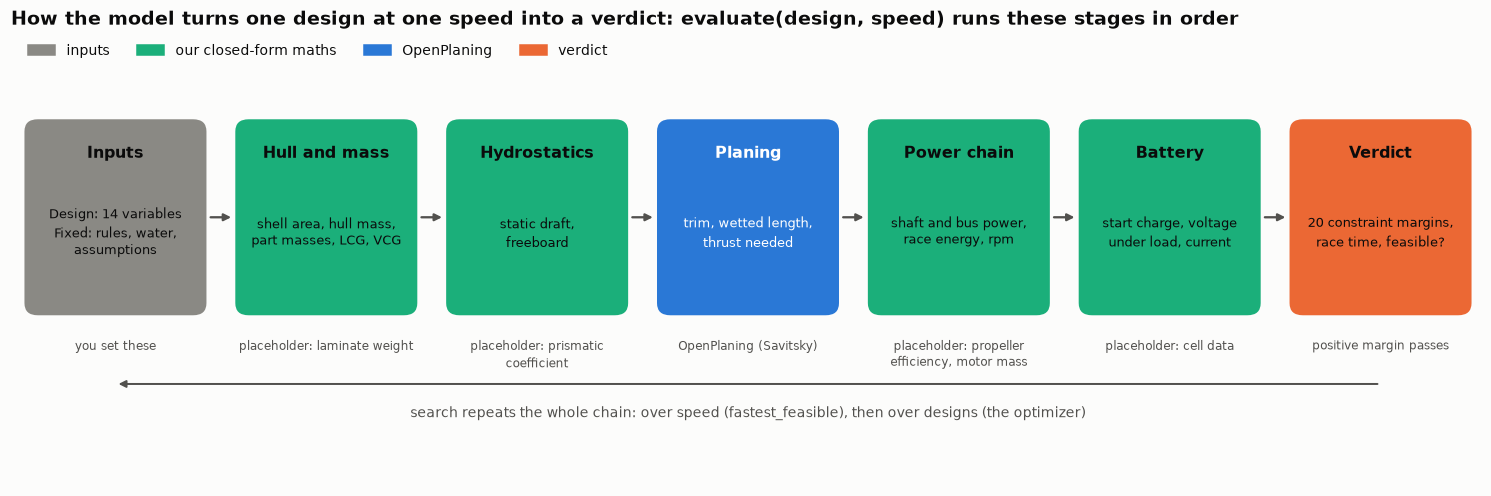

In [73]:
from dataclasses import fields
stages = [
    ("Inputs", f"Design: {len(fields(Design))} variables\nFixed: rules, water,\nassumptions", MUTED, "you set these"),
    ("Hull and mass", "shell area, hull mass,\npart masses, LCG, VCG", AQUA, "placeholder: laminate weight"),
    ("Hydrostatics", "static draft,\nfreeboard", AQUA, "placeholder: prismatic\ncoefficient"),
    ("Planing", "trim, wetted length,\nthrust needed", BLUE, "OpenPlaning (Savitsky)"),
    ("Power chain", "shaft and bus power,\nrace energy, rpm", AQUA, "placeholder: propeller\nefficiency, motor mass"),
    ("Battery", "start charge, voltage\nunder load, current", AQUA, "placeholder: cell data"),
    ("Verdict", f"{len(OV_AT.margins)} constraint margins,\nrace time, feasible?", ORANGE, "positive margin passes"),
]
W, G = 1.6, 0.3
fig, ax = plt.subplots(figsize=(13.4, 4.4), layout="constrained")
ax.set_xlim(-0.1, len(stages) * (W + G) - G + 0.1); ax.set_ylim(0, 4.4); ax.axis("off")
for i, (title, body, color, note) in enumerate(stages):
    x = i * (W + G)
    ax.add_patch(FancyBboxPatch((x, 1.7), W, 1.9, boxstyle="round,pad=0.02,rounding_size=0.12", fc=color, ec="none"))
    ax.text(x + W / 2, 3.28, title, ha="center", va="center", fontsize=10.5, fontweight="bold", color=ink_on(color))
    ax.text(x + W / 2, 2.5, body, ha="center", va="center", fontsize=8.5, color=ink_on(color), linespacing=1.4)
    ax.text(x + W / 2, 1.45, note, ha="center", va="top", fontsize=8, color=INK2, linespacing=1.3)
    if i < len(stages) - 1:
        ax.annotate("", xy=(x + W + G - 0.03, 2.65), xytext=(x + W + 0.03, 2.65), arrowprops=dict(arrowstyle="-|>", color=INK2, lw=1.5))
last = (len(stages) - 1) * (W + G)
ax.annotate("", xy=(W / 2, 1.0), xytext=(last + W / 2, 1.0), arrowprops=dict(arrowstyle="-|>", color=INK2, lw=1.3, connectionstyle="arc3,rad=0.0"))
ax.text((last + W) / 2, 0.78, "search repeats the whole chain: over speed (fastest_feasible), then over designs (the optimizer)", ha="center", va="top", fontsize=9, color=INK2)
ax.legend(handles=[Patch(color=MUTED, label="inputs"), Patch(color=AQUA, label="our closed-form maths"), Patch(color=BLUE, label="OpenPlaning"), Patch(color=ORANGE, label="verdict")],
          ncol=4, loc="upper left", bbox_to_anchor=(0, 1.02))
headline(fig, "How the model turns one design at one speed into a verdict: evaluate(design, speed) runs these stages in order")
plt.show()

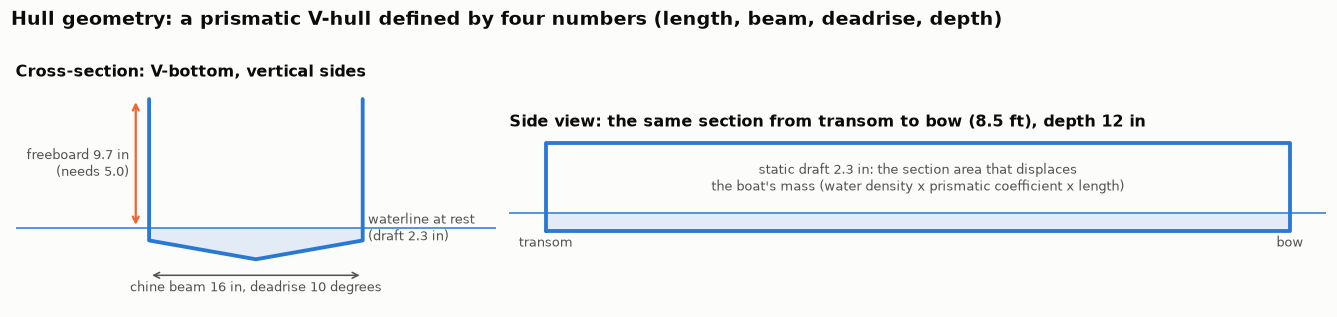

In [74]:
d, m = DESIGN, OV_AT.m
b, D, hc = d.beam_in, d.depth_in, chine_height_ft(d) * 12
draft, rule = m["static_draft_in"], FIXED.freeboard_rule_in + FIXED.wave_allowance_factor * FIXED.wave_height_in
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2), gridspec_kw=dict(width_ratios=[1, 1.7]), layout="constrained")
ax = axes[0]
ax.plot([-b / 2, -b / 2, 0, b / 2, b / 2], [D, hc, 0, hc, D], color=BLUE, lw=2.5)
ax.fill_between([-b / 2, 0, b / 2], [hc, 0, hc], [draft, draft, draft], where=[True, True, True], color=BLUE, alpha=0.12, lw=0)
ax.axhline(draft, color=BLUE, lw=1); ax.text(b / 2 + 0.4, draft, f"waterline at rest\n(draft {draft:.1f} in)", va="center", fontsize=8.5, color=INK2)
ax.annotate("", xy=(-b / 2 - 1.0, D), xytext=(-b / 2 - 1.0, draft), arrowprops=dict(arrowstyle="<->", color=ORANGE, lw=1.5))
ax.text(-b / 2 - 1.5, (D + draft) / 2, f"freeboard {m['freeboard_in']:.1f} in\n(needs {rule:.1f})", ha="right", va="center", fontsize=8.5, color=INK2)
ax.annotate("", xy=(-b / 2, -1.2), xytext=(b / 2, -1.2), arrowprops=dict(arrowstyle="<->", color=INK2, lw=1))
ax.text(0, -2.4, f"chine beam {b:.0f} in, deadrise {d.deadrise_deg:.0f} degrees", ha="center", fontsize=8.5, color=INK2)
ax.set_aspect("equal"); ax.set_xlim(-b / 2 - 10, b / 2 + 10); ax.set_ylim(-3.5, D + 1); ax.grid(False); ax.axis("off")
ax.set_title("Cross-section: V-bottom, vertical sides")
ax = axes[1]
L = d.length_ft * 12
ax.plot([0, L, L, 0, 0], [0, 0, D, D, 0], color=BLUE, lw=2.5)
ax.fill_between([0, L], 0, draft, color=BLUE, alpha=0.12, lw=0); ax.axhline(draft, color=BLUE, lw=1)
ax.text(L * 0.5, draft + (D - draft) / 2, f"static draft {draft:.1f} in: the section area that displaces\nthe boat's mass (water density x prismatic coefficient x length)", fontsize=8.5, color=INK2, ha="center", va="center")
ax.text(0, -2.2, "transom", ha="center", fontsize=8.5, color=INK2); ax.text(L, -2.2, "bow", ha="center", fontsize=8.5, color=INK2)
ax.set_aspect("equal"); ax.set_xlim(-5, L + 5); ax.set_ylim(-3.5, D + 1); ax.grid(False); ax.axis("off")
ax.set_title(f"Side view: the same section from transom to bow ({d.length_ft:g} ft), depth {D:g} in")
headline(fig, "Hull geometry: a prismatic V-hull defined by four numbers (length, beam, deadrise, depth)")
plt.show()

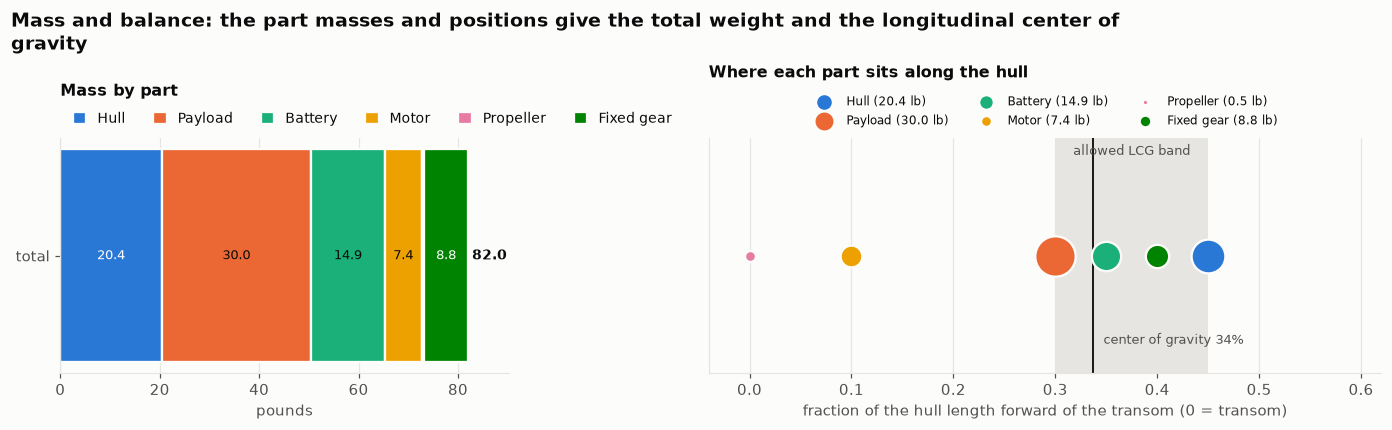

In [75]:
d, m = DESIGN, OV_AT.m
parts = [("Hull", m["hull_lb"], 0.45), ("Payload", FIXED.payload_lb, d.payload_x), ("Battery", m["battery_lb"], d.battery_x),
         ("Motor", m["motor_lb"], 0.10), ("Propeller", FIXED.prop_mass_lb, 0.0), ("Fixed gear", FIXED.fixed_equipment_lb, 0.40)]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8), gridspec_kw=dict(width_ratios=[1, 1.5]), layout="constrained")
ax = axes[0]
stacked_hbar(ax, ["total"], [[(n, w) for n, w, _ in parts]], min_frac=0.06); ax.set_xlabel("pounds"); ax.set_title("Mass by part", pad=28)
ax = axes[1]
lo, hi = FIXED.lcg_band
ax.axvspan(lo, hi, color=GRID, lw=0); ax.text((lo + hi) / 2, 0.93, "allowed LCG band", ha="center", fontsize=8.5, color=INK2, transform=ax.get_xaxis_transform())
for i, (n, w, x) in enumerate(parts):
    ax.scatter([x], [0], s=40 + w * 22, color=CAT[i], edgecolor=SURFACE, linewidth=1.5, zorder=4, label=f"{n} ({w:.1f} lb)")
ax.axvline(m["lcg_frac"], color=INK, lw=1.2); ax.text(m["lcg_frac"] + 0.01, -0.45, f"center of gravity {100 * m['lcg_frac']:.0f}%", fontsize=8.5, color=INK2)
ax.set_xlim(-0.04, 0.62); ax.set_ylim(-0.6, 0.6); ax.set_yticks([]); ax.grid(axis="y", visible=False)
ax.set_xlabel("fraction of the hull length forward of the transom (0 = transom)"); ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.0), fontsize=8, markerscale=0.5)
ax.set_title("Where each part sits along the hull", pad=40)
headline(fig, "Mass and balance: the part masses and positions give the total weight and the longitudinal center of gravity")
plt.show()

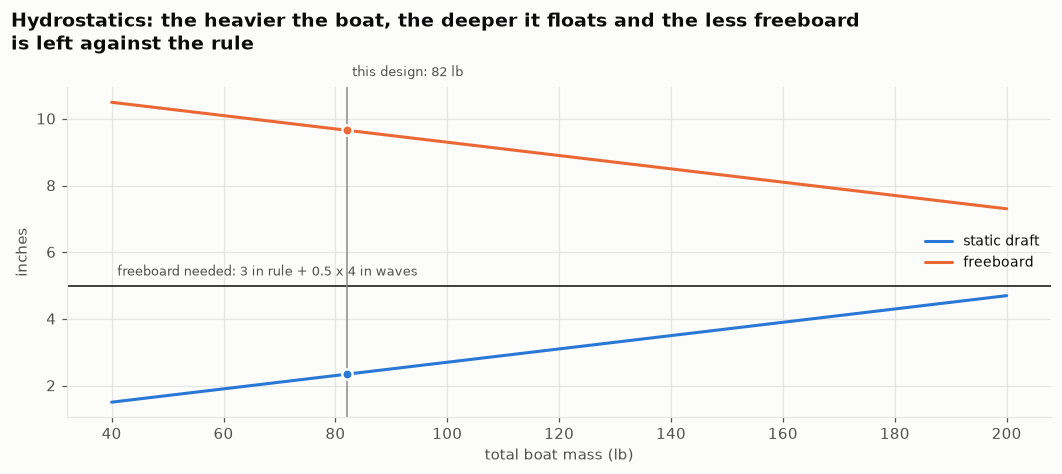

In [76]:
masses = np.linspace(40, 200, 81)
drafts = np.array([static_draft_ft(w, DESIGN, FIXED) * 12 for w in masses])
need = FIXED.freeboard_rule_in + FIXED.wave_allowance_factor * FIXED.wave_height_in
fig, ax = plt.subplots(figsize=(9.5, 4.2), layout="constrained")
ax.plot(masses, drafts, color=BLUE, label="static draft")
ax.plot(masses, DESIGN.depth_in - drafts, color=ORANGE, label="freeboard")
ax.axhline(need, color=INK, lw=1); ax.text(masses[0] + 1, need + 0.3, f"freeboard needed: {FIXED.freeboard_rule_in:g} in rule + {FIXED.wave_allowance_factor:g} x {FIXED.wave_height_in:g} in waves", fontsize=8.5, color=INK2)
m0 = OV_AT.m["mass_lb"]
dot(ax, m0, static_draft_ft(m0, DESIGN, FIXED) * 12, BLUE); dot(ax, m0, DESIGN.depth_in - static_draft_ft(m0, DESIGN, FIXED) * 12, ORANGE)
ax.axvline(m0, color=MUTED, lw=1); ax.text(m0 + 1, DESIGN.depth_in * 0.94, f"this design: {m0:.0f} lb", fontsize=8.5, color=INK2)
ax.set_xlabel("total boat mass (lb)"); ax.set_ylabel("inches"); ax.legend(loc="center right")
headline(fig, "Hydrostatics: the heavier the boat, the deeper it floats and the less freeboard is left against the rule")
plt.show()

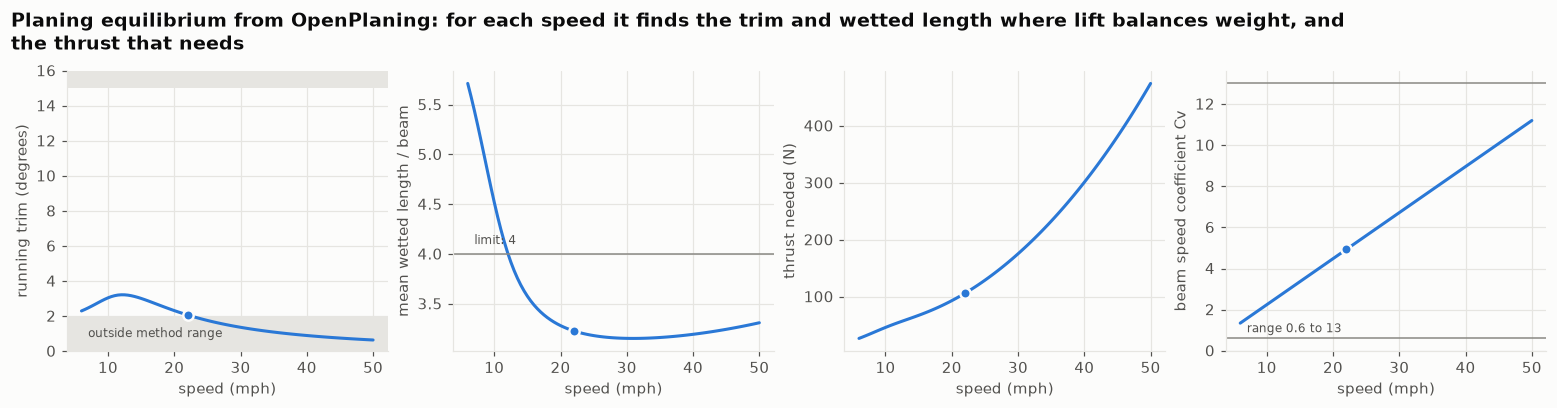

In [77]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharex=True, layout="constrained")
panels = [("running trim (degrees)", lambda r: r.m["trim_deg"]), ("mean wetted length / beam", lambda r: r.m["planing"]["lam"]),
          ("thrust needed (N)", lambda r: r.m["thrust_n"]), ("beam speed coefficient Cv", lambda r: r.m["planing"]["cv"])]
for ax, (label, g) in zip(axes, panels):
    ax.plot(OV_SPEEDS, series(OV, g), color=BLUE); ax.set_ylabel(label); ax.set_xlabel("speed (mph)")
    dot(ax, DESIGN.speed_mph, g(OV_AT) if OV_AT.m["planing"]["ok"] else np.nan, BLUE)
ax = axes[0]; ax.set_ylim(0, 16); ax.axhspan(0, 2, color=GRID, lw=0); ax.axhspan(15, 16, color=GRID, lw=0); ax.text(7, 1, "outside method range", fontsize=8, color=INK2, va="center")
axes[1].axhline(4, color=MUTED, lw=1); axes[1].text(7, 4.1, "limit: 4", fontsize=8, color=INK2)
axes[3].axhline(0.6, color=MUTED, lw=1); axes[3].axhline(13, color=MUTED, lw=1); axes[3].text(7, 0.9, "range 0.6 to 13", fontsize=8, color=INK2)
headline(fig, "Planing equilibrium from OpenPlaning: for each speed it finds the trim and wetted length where lift balances weight, and the thrust that needs")
plt.show()

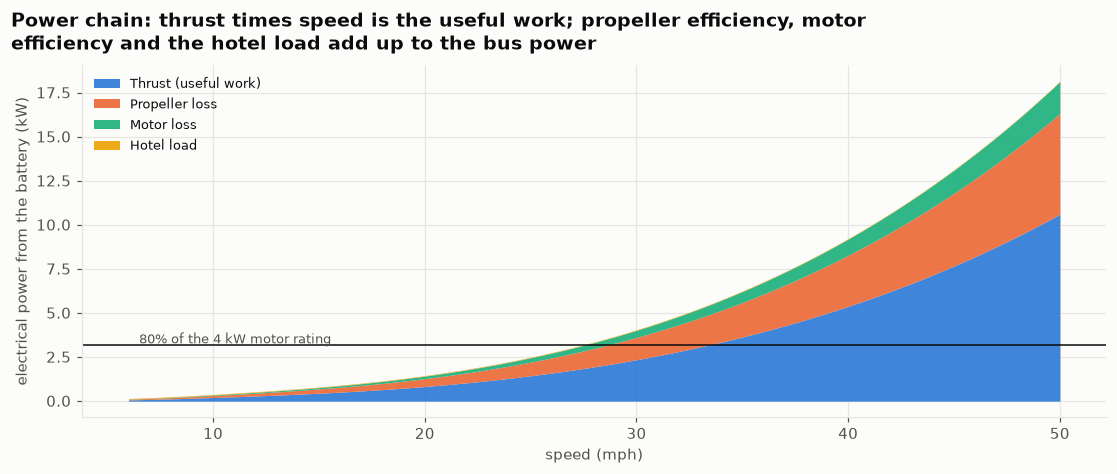

In [78]:
useful = series(OV, lambda r: r.m["thrust_n"]) * OV_SPEEDS * MPH / 1000
shaft = series(OV, lambda r: r.m["shaft_w"]) / 1000
bus = series(OV, lambda r: r.m["bus_w"]) / 1000
parts = [("Thrust (useful work)", useful), ("Propeller loss", shaft - useful), ("Motor loss", bus - FIXED.hotel_w / 1000 - shaft), ("Hotel load", np.full_like(bus, FIXED.hotel_w / 1000))]
ok_ = np.isfinite(bus)
fig, ax = plt.subplots(figsize=(10, 4.2), layout="constrained")
base = np.zeros(ok_.sum())
for k, (name, y) in enumerate(parts):
    ax.fill_between(OV_SPEEDS[ok_], base, base + y[ok_], color=CAT[k], lw=0, alpha=0.9, label=name); base = base + y[ok_]
ax.axhline(DESIGN.motor_kw * FIXED.rating_fraction, color=INK, lw=1)
ax.text(OV_SPEEDS[0] + 0.5, DESIGN.motor_kw * FIXED.rating_fraction + 0.08, f"{FIXED.rating_fraction:.0%} of the {DESIGN.motor_kw:g} kW motor rating", fontsize=8.5, color=INK2)
ax.set_xlabel("speed (mph)"); ax.set_ylabel("electrical power from the battery (kW)"); ax.legend(loc="upper left", fontsize=8.5)
headline(fig, "Power chain: thrust times speed is the useful work; propeller efficiency, motor efficiency and the hotel load add up to the bus power")
plt.show()

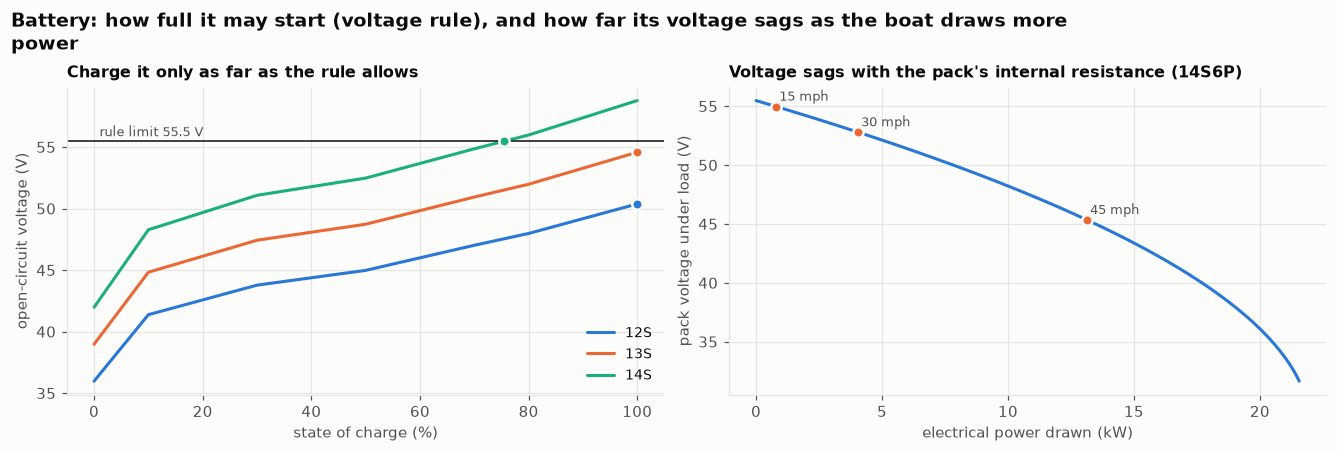

In [79]:
cell = FIXED.cell
fig, axes = plt.subplots(1, 2, figsize=(12, 4.0), layout="constrained")
ax = axes[0]
soc = np.linspace(0, 1, 101)
for S, c in zip((12, 13, 14), (BLUE, ORANGE, AQUA)):
    ax.plot(100 * soc, S * np.interp(soc, cell.soc, cell.ocv), color=c, label=f"{S}S")
    s0 = start_soc(S, FIXED); dot(ax, 100 * s0, S * ocv(s0, cell), c)
ax.axhline(FIXED.voltage_limit_v, color=INK, lw=1); ax.text(1, FIXED.voltage_limit_v + 0.4, f"rule limit {FIXED.voltage_limit_v} V", fontsize=8.5, color=INK2)
ax.set_xlabel("state of charge (%)"); ax.set_ylabel("open-circuit voltage (V)"); ax.set_title("Charge it only as far as the rule allows"); ax.legend(loc="lower right")
ax = axes[1]
bat = pack(DESIGN, FIXED); v_oc = DESIGN.series * ocv(start_soc(DESIGN.series, FIXED), cell)
power = np.linspace(0, 0.98 * v_oc ** 2 / (4 * bat["resistance_ohm"]), 200)
ax.plot(power / 1000, [loaded_voltage(v_oc, bat["resistance_ohm"], w) for w in power], color=BLUE)
for mph in (15, 30, 45):
    r = at_speed(DESIGN, mph)
    if r.m["planing"]["ok"]:
        dot(ax, r.m["bus_w"] / 1000, r.m["v_loaded"], ORANGE); ax.text(r.m["bus_w"] / 1000 + 0.12, r.m["v_loaded"] + 0.5, f"{mph} mph", fontsize=8.5, color=INK2)
ax.set_xlabel("electrical power drawn (kW)"); ax.set_ylabel("pack voltage under load (V)"); ax.set_title(f"Voltage sags with the pack's internal resistance ({DESIGN.series}S{DESIGN.parallel}P)")
headline(fig, "Battery: how full it may start (voltage rule), and how far its voltage sags as the boat draws more power")
plt.show()

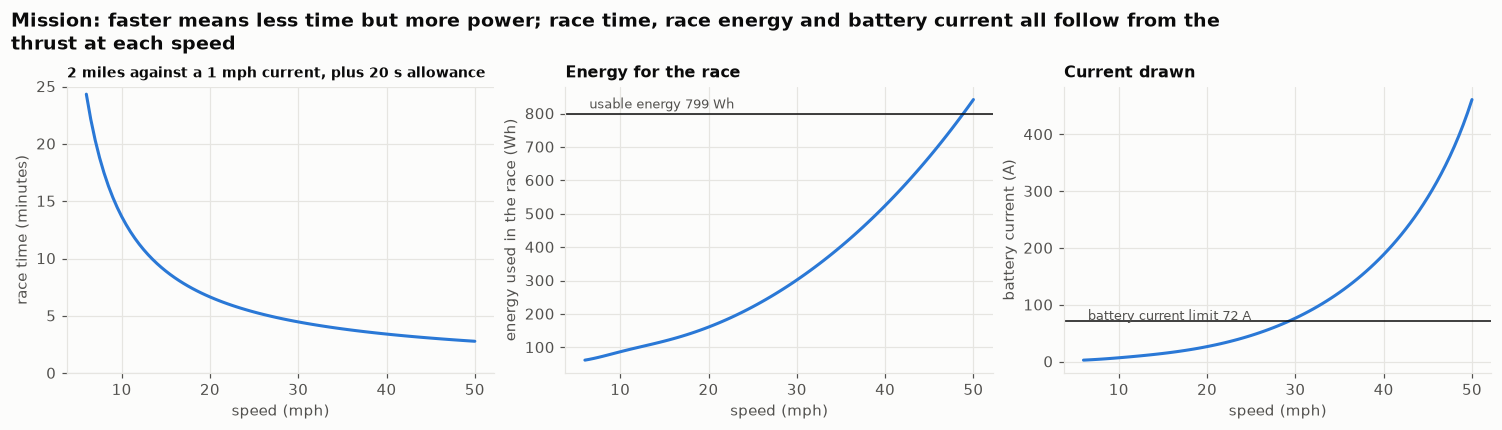

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), sharex=True, layout="constrained")
usable = FIXED.usable_energy_fraction * OV_AT.m["capacity_wh"] * OV_AT.m["start_soc"]
race_min = series(OV, lambda r: r.m["race_time_s"]) / 60
axes[0].plot(OV_SPEEDS, race_min, color=BLUE); axes[0].set_ylabel("race time (minutes)"); axes[0].set_ylim(0, 25)
axes[0].set_title(f"{FIXED.course_miles:g} miles against a {FIXED.current_mph:g} mph current, plus {FIXED.allowance_s:g} s allowance", fontsize=9)
e = series(OV, lambda r: r.m["energy_used_wh"])
axes[1].plot(OV_SPEEDS, e, color=BLUE); axes[1].axhline(usable, color=INK, lw=1); axes[1].text(OV_SPEEDS[0] + 0.5, usable * 1.02, f"usable energy {usable:.0f} Wh", fontsize=8.5, color=INK2)
axes[1].set_ylabel("energy used in the race (Wh)"); axes[1].set_title("Energy for the race")
axes[2].plot(OV_SPEEDS, series(OV, lambda r: r.m["current_a"]), color=BLUE)
lim = FIXED.rating_fraction * pack(DESIGN, FIXED)["current_limit_a"]
axes[2].axhline(lim, color=INK, lw=1); axes[2].text(OV_SPEEDS[0] + 0.5, lim * 1.02, f"battery current limit {lim:.0f} A", fontsize=8.5, color=INK2)
axes[2].set_ylabel("battery current (A)"); axes[2].set_title("Current drawn")
for ax in axes: ax.set_xlabel("speed (mph)")
headline(fig, "Mission: faster means less time but more power; race time, race energy and battery current all follow from the thrust at each speed")
plt.show()

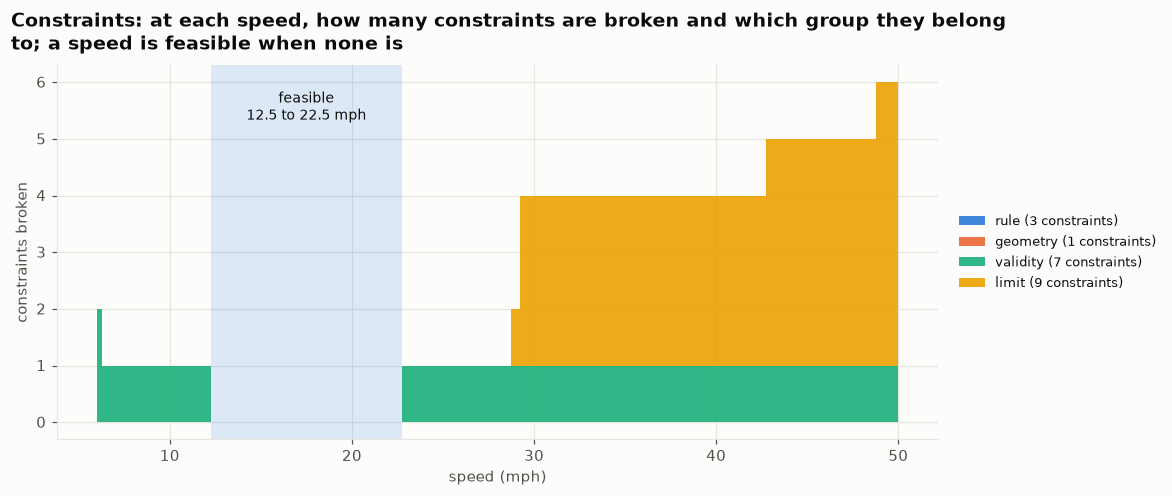

In [81]:
groups = {}
for r in OV:
    for k, (v, sc, g) in r.margins.items(): groups.setdefault(g, set()).add(k)
broken = {g: np.array([sum(r.margins[k][0] < 0 for k in ks if k in r.margins) for r in OV]) for g, ks in groups.items()}
fig, ax = plt.subplots(figsize=(10.5, 4.4), layout="constrained")
base = np.zeros(len(OV_SPEEDS))
for (g, y), c in zip(broken.items(), CAT):
    ax.fill_between(OV_SPEEDS, base, base + y, step="mid", color=c, lw=0, alpha=0.9, label=f"{g} ({len(groups[g])} constraints)"); base = base + y
total = sum(broken.values()); ok_ = total == 0
if ok_.any():
    lo_, hi_ = OV_SPEEDS[ok_].min(), OV_SPEEDS[ok_].max()
    ax.axvspan(lo_ - 0.25, hi_ + 0.25, color=BLUE, alpha=0.15, lw=0); ax.text((lo_ + hi_) / 2, ax.get_ylim()[1] * 0.93, f"feasible\n{lo_:g} to {hi_:g} mph", ha="center", va="top", fontsize=9, color=INK)
ax.set_xlabel("speed (mph)"); ax.set_ylabel("constraints broken"); ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8.5)
headline(fig, "Constraints: at each speed, how many constraints are broken and which group they belong to; a speed is feasible when none is")
plt.show()

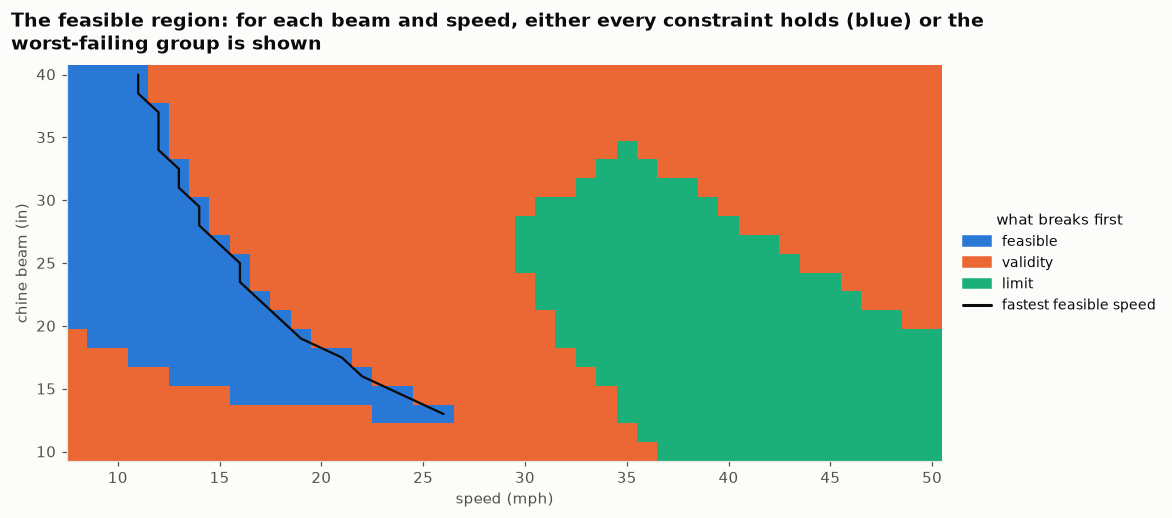

In [82]:
sp = np.arange(8, 50.01, 1.0); beams = np.arange(10, 40.01, 1.5)
classes = ["feasible", "validity", "limit", "rule", "geometry"]
Z = np.zeros((len(beams), len(sp)), dtype=int)
for j, bm in enumerate(beams):
    for i, s in enumerate(sp):
        r = at_speed(replace(DESIGN, beam_in=float(bm)), s)
        if r.feasible(): Z[j, i] = 0
        else:
            g = min(r.margins.items(), key=lambda kv: kv[1][0] / kv[1][1])[1][2]
            Z[j, i] = classes.index(g) if g in classes else 1
col = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA]
img = np.array([[mpl.colors.to_rgb(col[z]) for z in row] for row in Z])
fig, ax = plt.subplots(figsize=(10.5, 4.6), layout="constrained")
ax.imshow(img, origin="lower", aspect="auto", extent=[sp[0] - 0.5, sp[-1] + 0.5, beams[0] - 0.75, beams[-1] + 0.75]); ax.grid(False)
top = [sp[np.where(Z[j] == 0)[0].max()] if (Z[j] == 0).any() else np.nan for j in range(len(beams))]
ax.plot(top, beams, color=INK, lw=1.5)
ax.set_xlabel("speed (mph)"); ax.set_ylabel("chine beam (in)")
ax.legend(handles=[Patch(color=col[i], label=c) for i, c in enumerate(classes) if (Z == i).any()] + [plt.Line2D([], [], color=INK, label="fastest feasible speed")],
          loc="center left", bbox_to_anchor=(1.01, 0.5), title="what breaks first")
headline(fig, "The feasible region: for each beam and speed, either every constraint holds (blue) or the worst-failing group is shown")
plt.show()

In [83]:
mpl.rcParams.update(_RC_BEFORE)     # hand the plot defaults back so sections 8 to 16 look as they did; Part II re-applies the style

## 8. The fastest feasible speed

Speed is not really a free choice: for any design there is a highest speed at which every constraint still holds, and that is
the speed the boat should run. `fastest_feasible` scans speeds, keeps the feasible ones, and refines the upper edge. Race time
follows from it, so the optimizer only has to search the other variables.

In [84]:
def fastest_feasible(d, f=FIXED, lo=8.0, hi=60.0, step=4.0, tol=0.1, enforce_validity=None):
    ok = lambda s: evaluate(replace(d, speed_mph=s), f, s)
    feas = lambda r: r.feasible(enforce_validity)
    best = None
    for s in np.arange(lo, hi + 1e-9, step):
        r = ok(s)
        if feas(r): best = (s, r)
    if best is None:
        return None
    s_lo, r_lo = best
    s_hi = s_lo + step
    if s_hi <= hi:
        while s_hi - s_lo > tol:
            mid = (s_lo + s_hi) / 2
            r = ok(mid)
            if feas(r): s_lo, r_lo = mid, r
            else: s_hi = mid
    return s_lo, r_lo


def limiting(d, f=FIXED, nudge=0.5):
    # which constraints fail just above the fastest feasible speed: what is stopping the boat
    b = fastest_feasible(d, f)
    if b is None:
        return None, []
    v, _ = b
    return v, evaluate(replace(d, speed_mph=v + nudge), f, v + nudge).failing()

## 9. Baseline design

In [85]:
res = show(evaluate(DESIGN, FIXED), title=f"Baseline at {DESIGN.speed_mph:.0f} mph")

Baseline at 22 mph
  total mass                      82.0  lb   (hull 20.4, battery 14.9, motor 7.4)
  LCG                             33.7  % of length from transom
  static draft / freeboard   2.3 / 9.7  in
  running trim                    2.07  deg   wetted length/beam 3.23, Cv 4.93
  thrust needed                    106  N
  shaft / bus power         1.61 / 1.81  kW
  pack                            1512  Wh; start charge 76%, Voc 55.5 V, loaded 54.3 V, 33 A
  race energy                      183  Wh
  propeller                       2733  rpm, tip 72 ft/s, Kv needed 50
  race time                     6:02.9  min:sec
  FEASIBLE


In [86]:
best = fastest_feasible(DESIGN, FIXED)
if best:
    v, r = best
    show(r, title=f"Fastest feasible speed for the baseline design: {v:.1f} mph")
    print("  Just above that speed these constraints fail:", limiting(DESIGN, FIXED)[1])
else:
    print("No feasible speed. Failing at 22 mph:", evaluate(DESIGN, FIXED).failing())

Fastest feasible speed for the baseline design: 22.6 mph
  total mass                      82.0  lb   (hull 20.4, battery 14.9, motor 7.4)
  LCG                             33.7  % of length from transom
  static draft / freeboard   2.3 / 9.7  in
  running trim                    2.00  deg   wetted length/beam 3.22, Cv 5.05
  thrust needed                    110  N
  shaft / bus power         1.71 / 1.93  kW
  pack                            1512  Wh; start charge 76%, Voc 55.5 V, loaded 54.3 V, 36 A
  race energy                      190  Wh
  propeller                       2803  rpm, tip 73 ft/s, Kv needed 52
  race time                     5:53.9  min:sec
  FEASIBLE
  Just above that speed these constraints fail: ['trim_min']


## 10. Which constraint stops the boat?

At each speed, the margin of every constraint as a fraction of its scale. The first line to cross zero is the one limiting speed.

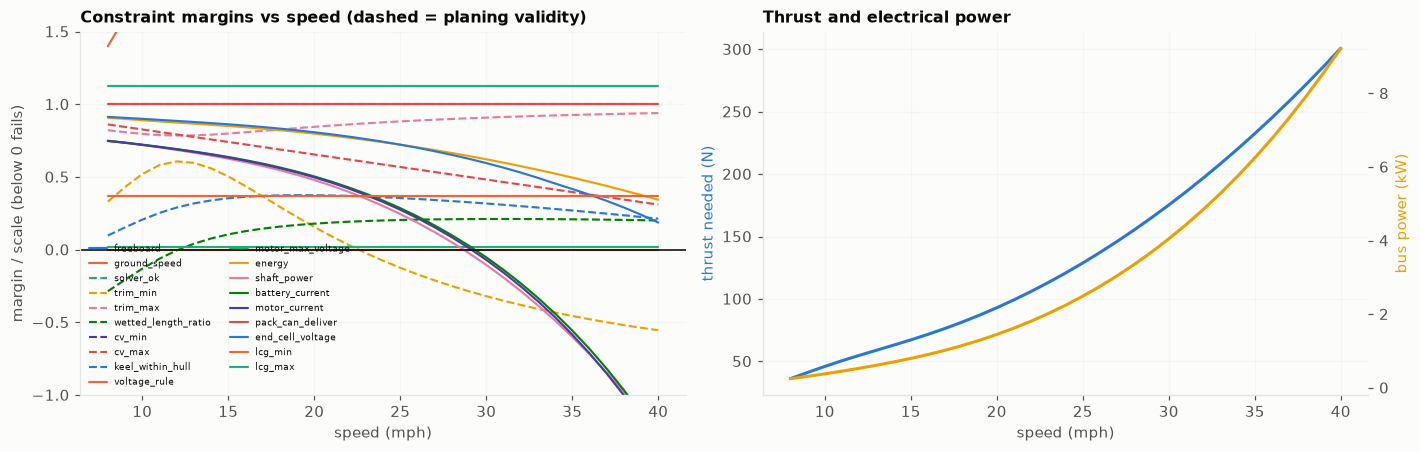

In [87]:
speeds = np.arange(8, 41, 1.0)
rows = [evaluate(replace(DESIGN, speed_mph=s), FIXED, s) for s in speeds]
names, groups = [], {}
for r in rows:
    for k, (_, _, grp) in r.margins.items():
        if k not in groups: names.append(k); groups[k] = grp

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
for k in names:
    if groups[k] == "geometry": continue
    y = [r.margins[k][0] / r.margins[k][1] if k in r.margins else np.nan for r in rows]
    ax.plot(speeds, y, label=k, lw=1.4, ls="--" if groups[k] == "validity" else "-")
ax.axhline(0, color="k", lw=1)
ax.set_ylim(-1, 1.5); ax.set_xlabel("speed (mph)"); ax.set_ylabel("margin / scale (below 0 fails)")
ax.set_title("Constraint margins vs speed (dashed = planing validity)"); ax.legend(fontsize=6, ncol=2)

ax = axes[1]
ok = np.array([r.m["planing"]["ok"] for r in rows])
thr = np.array([r.m.get("thrust_n", np.nan) for r in rows])
bus = np.array([r.m.get("bus_w", np.nan) for r in rows]) / 1000
ax.plot(speeds, thr, color="C0"); ax.set_ylabel("thrust needed (N)", color="C0"); ax.set_xlabel("speed (mph)")
ax2 = ax.twinx(); ax2.plot(speeds, bus, color="C3"); ax2.set_ylabel("bus power (kW)", color="C3"); ax2.grid(False)
ax.set_title("Thrust and electrical power")
plt.tight_layout(); plt.show()

## 11. Sweep one variable

`sweep` changes one design variable and reports, for each value, the fastest feasible speed and the race time that speed gives.
Gaps mean no speed in the scan was feasible. This is the quickest way to see whether a variable runs to an edge and what stops it.

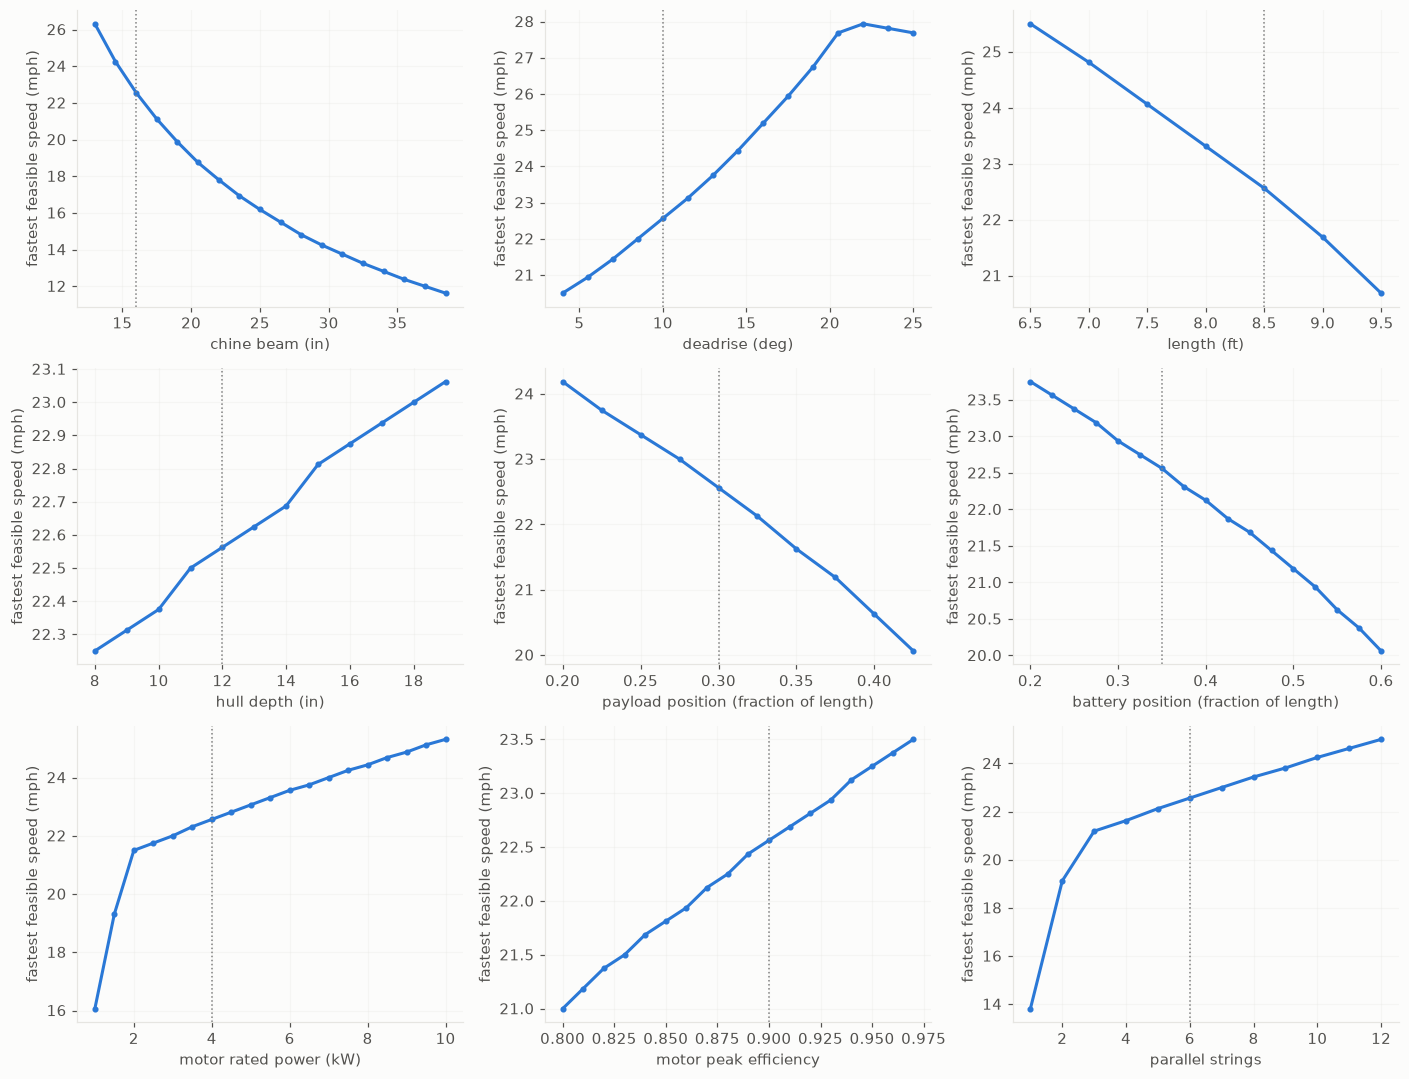

In [88]:
def sweep(var, values, f=FIXED, d=DESIGN):
    """`var` may name a Design field or a Fixed field."""
    out = []
    for x in values:
        if hasattr(d, var): dd, ff = replace(d, **{var: type(getattr(d, var))(x)}), f
        else: dd, ff = d, replace(f, **{var: type(getattr(f, var))(x)})
        b = fastest_feasible(dd, ff)
        out.append((x, None if b is None else b[0], None if b is None else b[1].m["race_time_s"],
                    None if b is None else b[1].m["thrust_n"]))
    return out


def plot_sweeps(specs, f=FIXED, d=DESIGN, ncols=3):
    n = len(specs); nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.3 * ncols, 3.3 * nrows), squeeze=False)
    for ax, (var, values, label) in zip(axes.flat, specs):
        res = sweep(var, values, f, d)
        xs = [r[0] for r in res]; vs = [np.nan if r[1] is None else r[1] for r in res]
        ax.plot(xs, vs, "o-", ms=3)
        ax.axvline(getattr(d if hasattr(d, var) else f, var), color="gray", ls=":", lw=1)
        ax.set_xlabel(label); ax.set_ylabel("fastest feasible speed (mph)")
        if all(np.isnan(vs)): ax.text(0.5, 0.5, "never feasible", transform=ax.transAxes, ha="center")
    for ax in axes.flat[n:]: ax.axis("off")
    plt.tight_layout(); plt.show()


plot_sweeps([
    ("beam_in", np.arange(10, 40, 1.5), "chine beam (in)"),
    ("deadrise_deg", np.arange(4, 26, 1.5), "deadrise (deg)"),
    ("length_ft", np.arange(6.5, 11.6, 0.5), "length (ft)"),
    ("depth_in", np.arange(6, 20, 1.0), "hull depth (in)"),
    ("payload_x", np.arange(0.20, 0.61, 0.025), "payload position (fraction of length)"),
    ("battery_x", np.arange(0.20, 0.61, 0.025), "battery position (fraction of length)"),
    ("motor_kw", np.arange(1.0, 10.1, 0.5), "motor rated power (kW)"),
    ("motor_eff", np.arange(0.80, 0.971, 0.01), "motor peak efficiency"),
    ("parallel", np.arange(1, 13, 1), "parallel strings"),
])

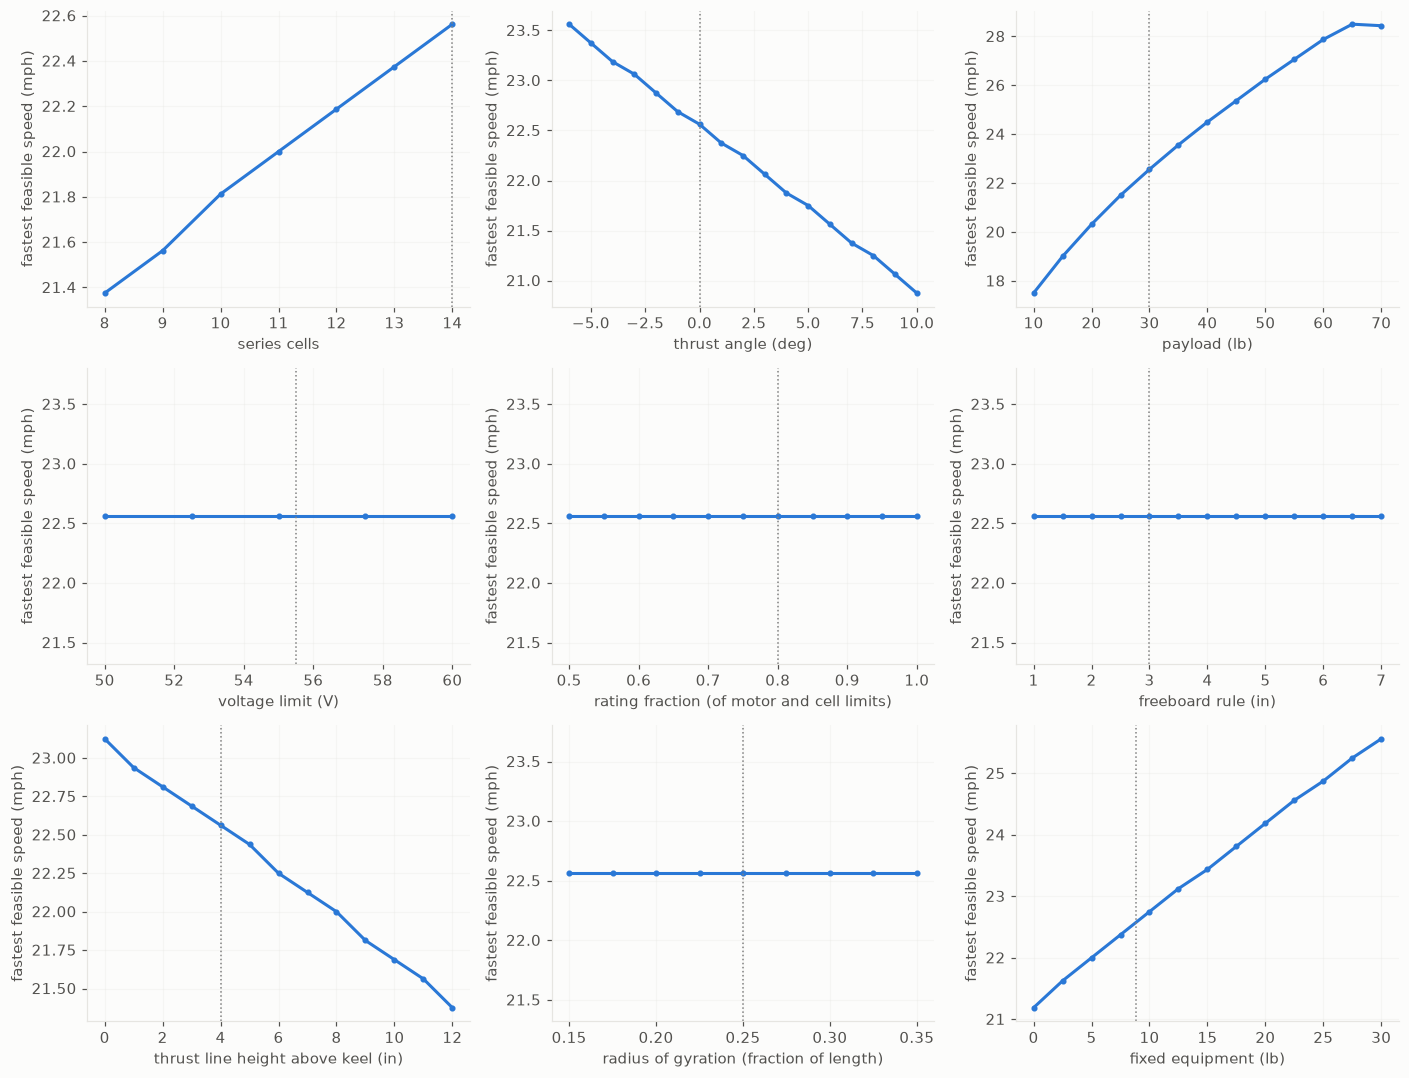

In [89]:
plot_sweeps([
    ("series", np.arange(8, 17, 1), "series cells"),
    ("thrust_angle_deg", np.arange(-6, 10.1, 1.0), "thrust angle (deg)"),
    ("payload_lb", np.arange(10, 71, 5), "payload (lb)"),
    ("voltage_limit_v", np.arange(40, 61, 2.5), "voltage limit (V)"),
    ("rating_fraction", np.arange(0.5, 1.01, 0.05), "rating fraction (of motor and cell limits)"),
    ("freeboard_rule_in", np.arange(1, 7.1, 0.5), "freeboard rule (in)"),
    ("thrust_height_in", np.arange(0, 12.1, 1.0), "thrust line height above keel (in)"),
    ("gyradius_frac", np.arange(0.15, 0.351, 0.025), "radius of gyration (fraction of length)"),
    ("fixed_equipment_lb", np.arange(0, 30.1, 2.5), "fixed equipment (lb)"),
])

## 12. Pack size: series and parallel counts

The battery decision variables. Fastest feasible speed for every combination. More series cells raise voltage and cut current; more
parallel strings add capacity and current headroom but also mass. 14S only works because the pack is charged partway to stay under 55.5 V.

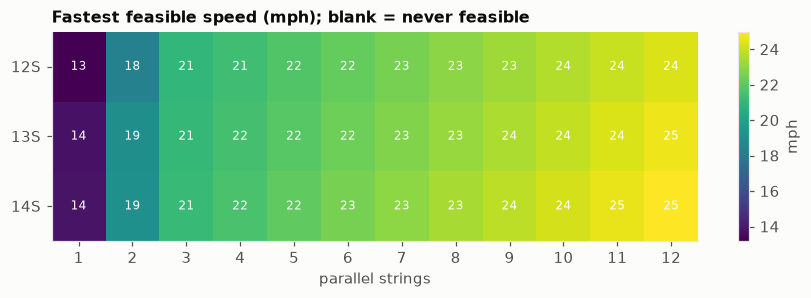

In [90]:
S_vals, P_vals = [12, 13, 14], list(range(1, 13))
grid = np.full((len(S_vals), len(P_vals)), np.nan)
for i, S in enumerate(S_vals):
    for j, P in enumerate(P_vals):
        b = fastest_feasible(replace(DESIGN, series=S, parallel=P), FIXED)
        if b: grid[i, j] = b[0]

fig, ax = plt.subplots(figsize=(8, 2.8))
im = ax.imshow(grid, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(P_vals)), P_vals); ax.set_yticks(range(len(S_vals)), [f"{s}S" for s in S_vals])
ax.set_xlabel("parallel strings"); ax.set_title("Fastest feasible speed (mph); blank = never feasible"); ax.grid(False)
for i in range(len(S_vals)):
    for j in range(len(P_vals)):
        if not np.isnan(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.0f}", ha="center", va="center", color="w", fontsize=8)
plt.colorbar(im, ax=ax, label="mph"); plt.tight_layout(); plt.show()

## 13. Interactive

Drag the sliders to change the design and see the full report at the current speed. (Needs `ipywidgets`; skipped silently if it is
missing.)

In [ ]:
try:
    import ipywidgets as w
    from IPython.display import clear_output

    fields = [
        ("length_ft", 7.0, 10.5, 0.25), ("beam_in", 10, 40, 0.5), ("deadrise_deg", 4, 25, 0.5), ("depth_in", 6, 20, 0.5),
        ("payload_x", 0.2, 0.6, 0.01), ("battery_x", 0.2, 0.6, 0.01), ("motor_kw", 1, 10, 0.25),
        ("motor_eff", 0.8, 0.97, 0.005), ("series", 12, 14, 1), ("parallel", 1, 12, 1), ("speed_mph", 8, 40, 0.5),
        ("pitch_in", 3, 24, 0.5), ("prop_diam_in", 3, 10, 0.5),
    ]
    sliders = {n: (w.IntSlider if isinstance(getattr(DESIGN, n), int) else w.FloatSlider)(
        value=getattr(DESIGN, n), min=lo, max=hi, step=st, description=n, continuous_update=False,
        style={"description_width": "110px"}, layout=w.Layout(width="420px")) for n, lo, hi, st in fields}
    enforce = w.Checkbox(value=True, description="enforce Savitsky validity limits")
    out = w.Output()

    def update(_=None):
        d = replace(DESIGN, **{n: s.value for n, s in sliders.items()})
        with out:
            clear_output(wait=True)
            show(evaluate(d, FIXED), enforce_validity=enforce.value, title=f"speed {d.speed_mph} mph")

    for s in list(sliders.values()) + [enforce]: s.observe(update, names="value")
    display(w.HBox([w.VBox(list(sliders.values()) + [enforce]), out]))
    update()
except ImportError:
    print("ipywidgets not installed; skipping the interactive panel")

TypeError: 'dict' object does not support the context manager protocol

## 14. Search for a good design

Differential evolution over the design variables, with the fastest feasible speed found for each candidate (so speed is not a
variable). Series and parallel counts are integers. Pitch, diameter and thrust angle are left out because the model has no propeller
efficiency yet, so they cannot change the answer.

This is a global search but not a proof: run it a few times with different seeds and compare. It takes about a minute.
Edit `BOUNDS` to change the search space. The hull length range is the plan's; the beam range is wide on purpose so the Savitsky
validity window shows up by itself.

In [92]:
# THESE ARE THE BOUNDS FOR THE DESIGN, THEY ARE MUTABLE as UPPER AND LOWER

BOUNDS = dict(
    length_ft=(3.0, 10.0), beam_in=(10, 40), deadrise_deg=(6, 16), depth_in=(8, 20),
    payload_x=(0.25, 0.50), battery_x=(0.25, 0.45), # bounds for payload and battery positions, as fractions of the length
    motor_kw=(2.0, 10.0), motor_eff=(0.85, 0.95), # bounds for motor power and efficiency
    series=(12, 14), parallel=(1, 12), # bounds for battery configuration, as integers to define as 2170 cells (this should prolly change)
)
INTEGER = {"series", "parallel"}
NAMES = list(BOUNDS)


def design_from(x):
    kw = {n: (int(round(v)) if n in INTEGER else float(v)) for n, v in zip(NAMES, x)}
    return replace(DESIGN, **kw)


def objective(x):
    d = design_from(x)
    b = fastest_feasible(d, FIXED, step=6.0, tol=0.25)
    if b is not None:
        return b[1].m["race_time_s"]
    return 1000.0 + evaluate(replace(d, speed_mph=20.0), FIXED, 20.0).violation()   # steer toward feasibility


def run_search(seed=1, popsize=8, maxiter=25):
    t0 = time.time()
    r = differential_evolution(objective, [BOUNDS[n] for n in NAMES], integrality=[n in INTEGER for n in NAMES],
                               seed=seed, popsize=popsize, maxiter=maxiter, tol=1e-6, polish=False, updating="deferred")
    return r, time.time() - t0

In [93]:
sr, secs = run_search(seed=1)
best_design = design_from(sr.x)
print(f"search finished in {secs:.0f} s, {sr.nfev} candidate designs, best race time {sr.fun:.1f} s")
b = fastest_feasible(best_design, FIXED)
if b:
    best_design = replace(best_design, speed_mph=b[0])     # exact, so it sits right on the limit
    show(evaluate(best_design, FIXED), title=f"Best design found, running at {best_design.speed_mph:.1f} mph")
    print("  Just above that speed these constraints fail:", limiting(best_design, FIXED)[1])
else:
    print("No feasible design was found. Try more iterations or wider bounds.")

search finished in 18 s, 2080 candidate designs, best race time 167.5 s
Best design found, running at 49.9 mph
  total mass                      97.0  lb   (hull 11.1, battery 27.3, motor 19.3)
  LCG                             30.0  % of length from transom
  static draft / freeboard   7.6 / 9.4  in
  running trim                    2.04  deg   wetted length/beam 1.45, Cv 12.99
  thrust needed                    158  N
  shaft / bus power         5.42 / 5.90  kW
  pack                            2772  Wh; start charge 76%, Voc 55.5 V, loaded 53.4 V, 110 A
  race energy                      274  Wh
  propeller                       6204  rpm, tip 162 ft/s, Kv needed 116
  race time                     2:47.1  min:sec
  FEASIBLE
  Just above that speed these constraints fail: ['cv_max']


In [94]:
print(f"{'variable':<14}{'value':>10}    position in range")
for n in NAMES:
    lo, hi = BOUNDS[n]; v = getattr(best_design, n); frac = (v - lo) / (hi - lo) if hi > lo else 0.5
    edge = "  <-- at the lower bound" if frac < 0.02 else "  <-- at the upper bound" if frac > 0.98 else ""
    print(f"{n:<14}{v:>10.3f}    {100 * frac:5.0f}%{edge}")

variable           value    position in range
length_ft          3.280        4%
beam_in           11.861        6%
deadrise_deg      15.497       95%
depth_in          17.035       75%
payload_x          0.257        3%
battery_x          0.402       76%
motor_kw           9.912       99%  <-- at the upper bound
motor_eff          0.924       74%
series            14.000      100%  <-- at the upper bound
parallel          11.000       91%


### Reading the result

In a typical run the optimizer takes the narrowest beam and a high deadrise, and it stops on the Savitsky trim floor
(2 degrees), not on motor power. Both are the model telling you what it is missing, not design advice:

- Nothing needs width. There is no roll stability or payload footprint constraint, so beam runs to its lower bound.
- Higher deadrise and narrower beam keep trim above 2 degrees as speed rises, so the search leans on them.
- Speeds far above the plan's 18 to 30 mph target come from an unvalidated resistance estimate. Treat them as a statement about
  the model.

Look at the "at the lower/upper bound" flags: each one is a place where a real constraint (stability, payload, ride) is absent.

## 15. Sanity checks on the regime

Planing needs the boat to be fast enough for dynamic lift. Two dimensionless numbers, computed for the baseline:
the volumetric Froude number `V / sqrt(g x volume^(1/3))` (planing is roughly 2.3 or more) and the beam speed coefficient
`Cv = V / sqrt(g x beam)` (Savitsky's method covers 0.6 to 13). These are rules of thumb, not limits from the method's authors.

In [95]:
m0 = evaluate(DESIGN, FIXED).m
vol_ft3 = m0["mass_lb"] / FIXED.water_lb_ft3
print(f"loaded mass {m0['mass_lb']:.1f} lb, displaced volume {vol_ft3:.2f} ft^3")
for mph in (8, 10, 12, 15, 18, 22, 26, 30):
    v = mph * 5280 / 3600
    fn = v / math.sqrt(32.174 * vol_ft3 ** (1 / 3))
    cv = v / math.sqrt(32.174 * DESIGN.beam_in / 12)
    print(f"  {mph:>2} mph   volumetric Froude {fn:4.1f}   Cv {cv:4.1f}")

loaded mass 82.0 lb, displaced volume 1.31 ft^3
   8 mph   volumetric Froude  2.0   Cv  1.8
  10 mph   volumetric Froude  2.5   Cv  2.2
  12 mph   volumetric Froude  3.0   Cv  2.7
  15 mph   volumetric Froude  3.7   Cv  3.4
  18 mph   volumetric Froude  4.4   Cv  4.0
  22 mph   volumetric Froude  5.4   Cv  4.9
  26 mph   volumetric Froude  6.4   Cv  5.8
  30 mph   volumetric Froude  7.4   Cv  6.7


## 16. Try the plan's boat

The plan's dimensions (34 in beam, 8.5 ft, 95 lb class) with the validity limits switched off, to see what OpenPlaning reports when
the boat is much lighter than its beam calls for. Trim falls below 2 degrees, so the result is an extrapolation.

In [96]:
plan_boat = replace(DESIGN, beam_in=34.0, parallel=4)
for mph in (10, 14, 18, 22, 30):
    r = evaluate(replace(plan_boat, speed_mph=mph), FIXED, mph)
    p = r.m["planing"]
    if p["ok"]:
        print(f"{mph:>3} mph  trim {p['trim_deg']:.2f} deg  thrust {p['thrust_n']:.0f} N  wetted length/beam {p['lam']:.2f}  "
              f"validity failures: {[k for k in r.failing(True) if r.margins[k][2] == 'validity']}")

 10 mph  trim 2.28 deg  thrust 65 N  wetted length/beam 1.79  validity failures: []
 14 mph  trim 1.75 deg  thrust 98 N  wetted length/beam 1.60  validity failures: ['trim_min']
 18 mph  trim 1.30 deg  thrust 145 N  wetted length/beam 1.54  validity failures: ['trim_min']
 22 mph  trim 1.00 deg  thrust 194 N  wetted length/beam 1.53  validity failures: ['trim_min', 'keel_within_hull']
 30 mph  trim 0.66 deg  thrust 225 N  wetted length/beam 1.50  validity failures: ['trim_min', 'keel_within_hull']


# Part II. Exploring parameters and approaches

Part I built the model and poked at it by hand. Part II is a set of **lenses** on the same model for exploring it more broadly:
different ways to search the design space, different objectives, and different ways to look at what a change in a parameter does.
Nothing here argues for a conclusion. Each chart says what it plots; what it means is for you to read off.

**How it works.** The cell under *Controls* sets a few knobs (seeds, a target speed, which designs to compare, how many random
designs to draw). The *Approaches* cells then search the design space several ways and collect the results in one dictionary,
`DESIGNS`. Every later lens reads from `DESIGNS`, so you can add your own design with `EXTRA_DESIGNS` and it appears in the
charts. Single-design lenses use `SUBJECT`; line charts overlay the designs in `COMPARE`.

| Lens | What it explores |
| --- | --- |
| Approaches | Differential evolution (several seeds), random search, dual annealing and a local search on the same objective and budget; plus two other objectives (lightest boat, least energy at a target speed) |
| Designs side by side | Hull shape, sizing and performance numbers, and weight and power breakdowns for every design |
| Physics against speed | Thrust, trim, wetted length, lift-to-drag, race time, and how close each power and energy limit comes |
| The battery | The voltage rule, voltage sag for different parallel counts, charge and cell voltage through the race |
| Constraints | Every constraint's margin against speed; which one binds across a grid of two variables; what blocks random designs |
| Parameters | One variable at a time, two at a time (colored by any metric), every variable against speed, parallel coordinates |
| Assumptions | Each placeholder in `Fixed` swept in turn, and a ranking by how much it moves the result |
| What-ifs | Variants of the subject design |

Everything runs on the placeholder data from Part I, so read the shapes of the curves rather than the numbers.
Run the overview and Part I down to section 14 first (the overview's first cell defines the plot style). The *Approaches* cells run eight searches, about two minutes in total; the rest take seconds
each.

In [97]:
# The palette and helpers come from the overview's style cell. Re-apply the style (the overview hands the plot defaults back
# when it ends) and add the two helpers that need fastest_feasible from section 8.
mpl.rcParams.update(STYLE)


def with_fixed(f, path, value):
    # change one assumption, including the ones nested inside Fixed.cell
    if path.startswith("cell."):
        return replace(f, cell=replace(f.cell, **{path[5:]: value}))
    return replace(f, **{path: value})


def fastest_boat(d, f=FIXED, enforce_validity=None):
    v, r = fastest_feasible(d, f, enforce_validity=enforce_validity)
    return replace(d, speed_mph=v), r

In [98]:
# ---- Controls: edit these, then re-run this cell and the ones below ----
SEEDS = (1, 2, 3)                 # differential-evolution seeds to try
TARGET_MPH = 25.0                 # speed for the "lightest boat" and "least energy" objectives
SPEED_SCAN = np.arange(6, 60.01, 0.5)    # speeds drawn in the line charts
SAMPLE_N = 500                    # random designs drawn for the sampling lenses
EXTRA_DESIGNS = {}                # your own designs, e.g. {"wide": replace(DESIGN, beam_in=30, parallel=8)}
SUBJECT = None                    # the design the single-design lenses use (a name from DESIGNS); None = best race time
COMPARE = None                    # designs overlaid in the line charts; None = the subject plus up to three others

# Pick any pair of variables, and the quantity to color by.
MAP_PAIRS = [("beam_in", np.linspace(*BOUNDS["beam_in"], 14), "chine beam (in)", "deadrise_deg", np.linspace(*BOUNDS["deadrise_deg"], 11), "deadrise (degrees)"),
             ("motor_kw", np.linspace(*BOUNDS["motor_kw"], 9), "motor power (kW)", "parallel", np.arange(BOUNDS["parallel"][0], BOUNDS["parallel"][1] + 1), "parallel strings"),
             ("length_ft", np.linspace(*BOUNDS["length_ft"], 8), "length (ft)", "beam_in", np.linspace(*BOUNDS["beam_in"], 14), "chine beam (in)")]
MAP_METRICS = {"fastest feasible speed (mph)": lambda v, r: v, "race time (s)": lambda v, r: r.m["race_time_s"],
               "total mass (lb)": lambda v, r: r.m["mass_lb"], "race energy (Wh)": lambda v, r: r.m["energy_used_wh"]}
MAP_METRIC = "fastest feasible speed (mph)"

## Approaches

The same design space (`BOUNDS`) searched four ways with the same budget of about 2,000 evaluated designs, and with three
different objectives. The first chart plots the best race time found against the number of designs evaluated; the second shows
where each result puts every variable inside its range, with the edges shaded.

Things to try: change `SEEDS`, change `TARGET_MPH`, widen `BOUNDS` in section 14, or add a method to `run_method`.

In [99]:
# --- Approaches: the same design space searched different ways -------------------------------------------------
class Tracked:
    # wraps an objective so every method is judged on the same thing: the best value after each evaluation
    def __init__(self, fn):
        self.fn, self.best, self.best_x, self.trace = fn, float("inf"), None, []

    def __call__(self, x):
        v = float(self.fn(x))
        if v < self.best: self.best, self.best_x = v, np.array(x, dtype=float)
        self.trace.append(self.best)
        return v


def obj_race_time(x):
    return objective(x)                                    # section 14's objective: race time at the fastest feasible speed


def _at_target(x):
    d = replace(design_from(x), speed_mph=TARGET_MPH)
    return d, evaluate(d, FIXED, TARGET_MPH)


def obj_lightest(x):
    d, r = _at_target(x)                                   # least total mass among boats that can run TARGET_MPH
    return r.m["mass_lb"] if r.feasible() else 1000.0 + 100 * r.violation()


def obj_least_energy(x):
    d, r = _at_target(x)                                   # least race energy among boats that can run TARGET_MPH
    return r.m["energy_used_wh"] if r.feasible() else 1000.0 + 100 * r.violation()


def run_method(method, fn, seed=0, budget=2080):
    from scipy.optimize import dual_annealing, minimize
    t, bounds = Tracked(fn), [BOUNDS[n] for n in NAMES]
    t0 = time.time()
    if method == "de":
        differential_evolution(t, bounds, integrality=[n in INTEGER for n in NAMES], seed=seed, popsize=8, maxiter=25,
                               tol=1e-6, polish=False, updating="deferred")
    elif method == "random":
        rng = np.random.default_rng(seed)
        for _ in range(budget): t(np.array([rng.uniform(*b) for b in bounds]))
    elif method == "annealing":
        dual_annealing(t, bounds, seed=seed, maxfun=budget)
    elif method == "powell":
        minimize(t, np.array([(lo + hi) / 2 for lo, hi in bounds]), method="Powell", bounds=bounds, options=dict(maxfev=budget))
    return dict(x=t.best_x, value=t.best, trace=t.trace, nfev=len(t.trace), secs=time.time() - t0)

In [100]:
SPECS = ([(f"DE seed {s}", "de", obj_race_time, s, "race time") for s in SEEDS]
         + [("Random search", "random", obj_race_time, 0, "race time"), ("Dual annealing", "annealing", obj_race_time, 0, "race time"),
            ("Powell (local)", "powell", obj_race_time, 0, "race time"),
            (f"Lightest at {TARGET_MPH:g} mph", "de", obj_lightest, 1, "lightest"), (f"Least energy at {TARGET_MPH:g} mph", "de", obj_least_energy, 1, "least energy")])
RUNS = []
for label, method, fn, seed, goal in SPECS:
    out = run_method(method, fn, seed)
    b = fastest_feasible(design_from(out["x"]), FIXED) if out["x"] is not None else None
    if b is None:
        print(f"{label}: no feasible design found"); continue
    d, r = replace(design_from(out["x"]), speed_mph=b[0]), b[1]
    RUNS.append(dict(label=label, goal=goal, method=method, design=d, result=r, **out))

DESIGNS = {run["label"]: (run["design"], run["result"]) for run in RUNS}
for name, d in EXTRA_DESIGNS.items():
    b = fastest_feasible(d, FIXED)
    if b: DESIGNS[name] = (replace(d, speed_mph=b[0]), b[1])
    else: print(f"{name}: no feasible speed")
DNAMES = list(DESIGNS)
DCOLOR = {n: CAT[i % len(CAT)] for i, n in enumerate(DNAMES)}
if SUBJECT is None:
    SUBJECT = min((run for run in RUNS if run["goal"] == "race time"), key=lambda run: run["value"])["label"]
if COMPARE is None:
    COMPARE = [SUBJECT] + [n for n in (f"Lightest at {TARGET_MPH:g} mph", f"Least energy at {TARGET_MPH:g} mph", "Random search") if n in DESIGNS and n != SUBJECT]
    COMPARE = (COMPARE + [n for n in DNAMES if n not in COMPARE])[:4]
SUBJ, SUBJ_R = DESIGNS[SUBJECT]

print(f"{'design':<26}{'objective':>10}{'evals':>7}{'secs':>6}   {'mph':>5} {'race s':>7} {'lb':>6} {'Wh':>6} {'kW':>5}  S x P")
for run in RUNS:
    d, r = run["design"], run["result"]
    print(f"{run['label']:<26}{run['value']:>10.1f}{run['nfev']:>7}{run['secs']:>6.0f}   {d.speed_mph:>5.1f} {r.m['race_time_s']:>7.0f} "
          f"{r.m['mass_lb']:>6.1f} {r.m['capacity_wh']:>6.0f} {d.motor_kw:>5.1f}  {d.series}S{d.parallel}P")
print(f"\nsubject: {SUBJECT}   overlaid in line charts: {COMPARE}")

design                     objective  evals  secs     mph  race s     lb     Wh    kW  S x P
DE seed 1                      167.5   2080    18    49.9     167   97.0   2772   9.9  14S11P
DE seed 2                      166.9   2080    17    50.1     167   93.8   2808   7.8  13S12P
DE seed 3                      166.4   2080    18    50.2     166   97.3   2772   8.9  14S11P
Random search                  177.8   2080    16    46.6     178   84.5   2016   8.6  14S8P
Dual annealing                 176.5   2080    17    47.0     177   89.7   2520   9.8  14S10P
Powell (local)                 179.8    655     6    46.1     180   79.0   1512   7.4  14S6P
Lightest at 25 mph              55.8   2080     1    26.9     298   55.8    432   2.0  12S2P
Least energy at 25 mph          78.8   2080     1    30.4     265   59.3    468   2.1  13S2P

subject: DE seed 3   overlaid in line charts: ['DE seed 3', 'Lightest at 25 mph', 'Least energy at 25 mph', 'Random search']


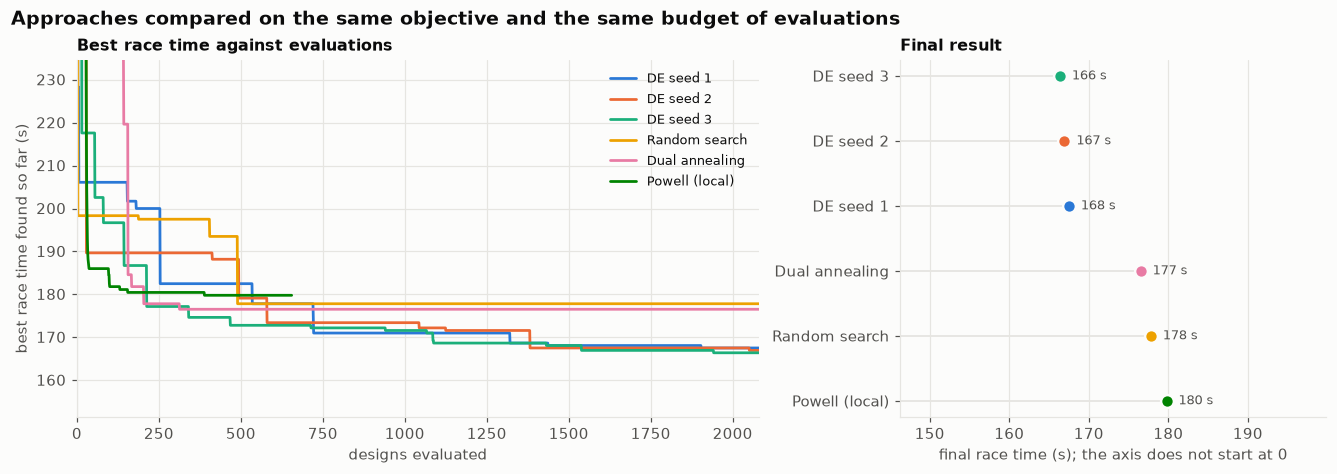

In [101]:
race_runs = [run for run in RUNS if run["goal"] == "race time"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw=dict(width_ratios=[1.6, 1]), layout="constrained")
ax = axes[0]
for run in race_runs:
    ax.plot(np.arange(1, run["nfev"] + 1), run["trace"], color=DCOLOR[run["label"]], label=run["label"], lw=1.8)
ends = [run["value"] for run in race_runs]
early = [run["trace"][min(150, run["nfev"] - 1)] for run in race_runs]
ax.set_ylim(min(ends) - 15, max(early) + 15); ax.set_xlim(0, max(run["nfev"] for run in race_runs))
ax.set_xlabel("designs evaluated"); ax.set_ylabel("best race time found so far (s)"); ax.legend(loc="upper right", fontsize=8.5)
ax.set_title("Best race time against evaluations")
ax = axes[1]
srt = sorted(race_runs, key=lambda run: -run["value"])
for i, run in enumerate(srt):
    ax.hlines(i, 0, run["value"], color=GRID, lw=1.2, zorder=1); dot(ax, run["value"], i, DCOLOR[run["label"]], s=70)
    ax.text(run["value"] + 1.5, i, f"{run['value']:.0f} s", va="center", fontsize=8.5, color=INK2)
ax.set_yticks(range(len(srt)), [run["label"] for run in srt])
span = max(ends) - min(ends); ax.set_xlim(min(ends) - max(span, 5) * 1.5, max(ends) + max(span, 5) * 1.5)
ax.grid(axis="y", visible=False); ax.set_xlabel("final race time (s); the axis does not start at 0"); ax.set_title("Final result")
headline(fig, "Approaches compared on the same objective and the same budget of evaluations")
plt.show()

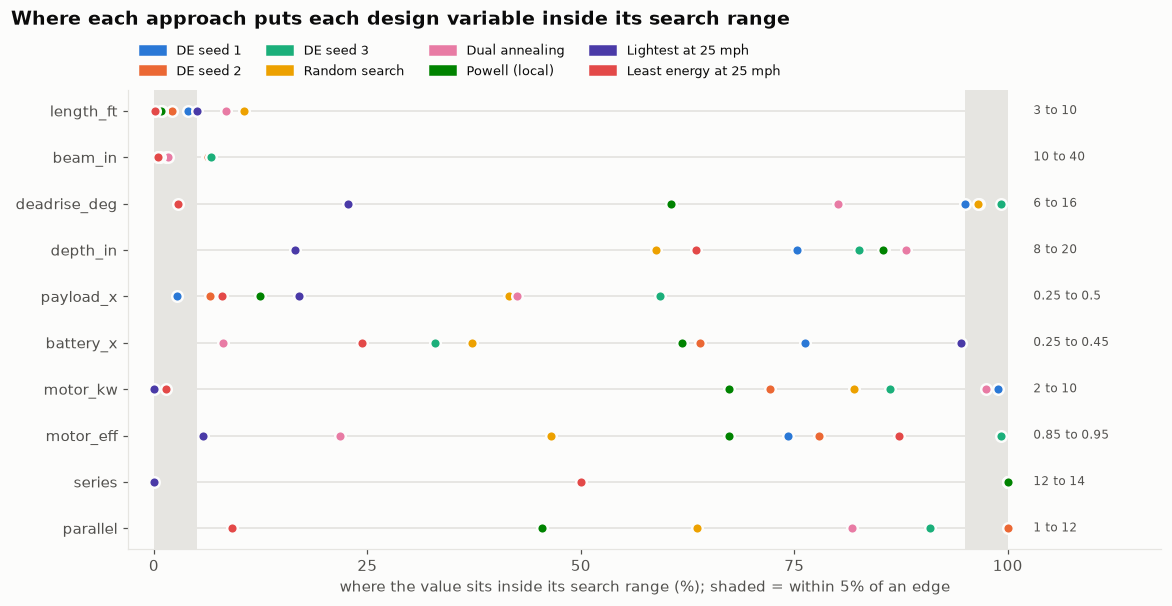

In [102]:
fig, ax = plt.subplots(figsize=(10.5, 5.4), layout="constrained")
ax.axvspan(0, 5, color=GRID, lw=0); ax.axvspan(95, 100, color=GRID, lw=0)
for i, n in enumerate(NAMES):
    lo, hi = BOUNDS[n]
    ax.hlines(i, 0, 100, color=GRID, lw=1.2, zorder=1)
    for name, (d, _) in DESIGNS.items():
        dot(ax, 100 * (getattr(d, n) - lo) / (hi - lo), i, DCOLOR[name], s=48, z=5)
    ax.text(103, i, f"{lo:g} to {hi:g}", fontsize=8, color=INK2, va="center")
ax.set_yticks(range(len(NAMES)), NAMES); ax.invert_yaxis(); ax.grid(False)
ax.set_xlim(-3, 118); ax.set_xticks([0, 25, 50, 75, 100]); ax.set_xlabel("where the value sits inside its search range (%); shaded = within 5% of an edge")
ax.legend(handles=[Patch(color=DCOLOR[n], label=n) for n in DNAMES], ncol=4, loc="lower left", bbox_to_anchor=(0, 1.0), fontsize=8.5)
headline(fig, "Where each approach puts each design variable inside its search range")
plt.show()

## Designs side by side

Every design in `DESIGNS`: hull cross-section and plan view, a grid of sizing and performance numbers, and stacked bars for where
the weight and the battery power go. The propeller and motor loss split follows from two placeholders (`prop_efficiency` and
`motor_eff`), so it moves when they do.

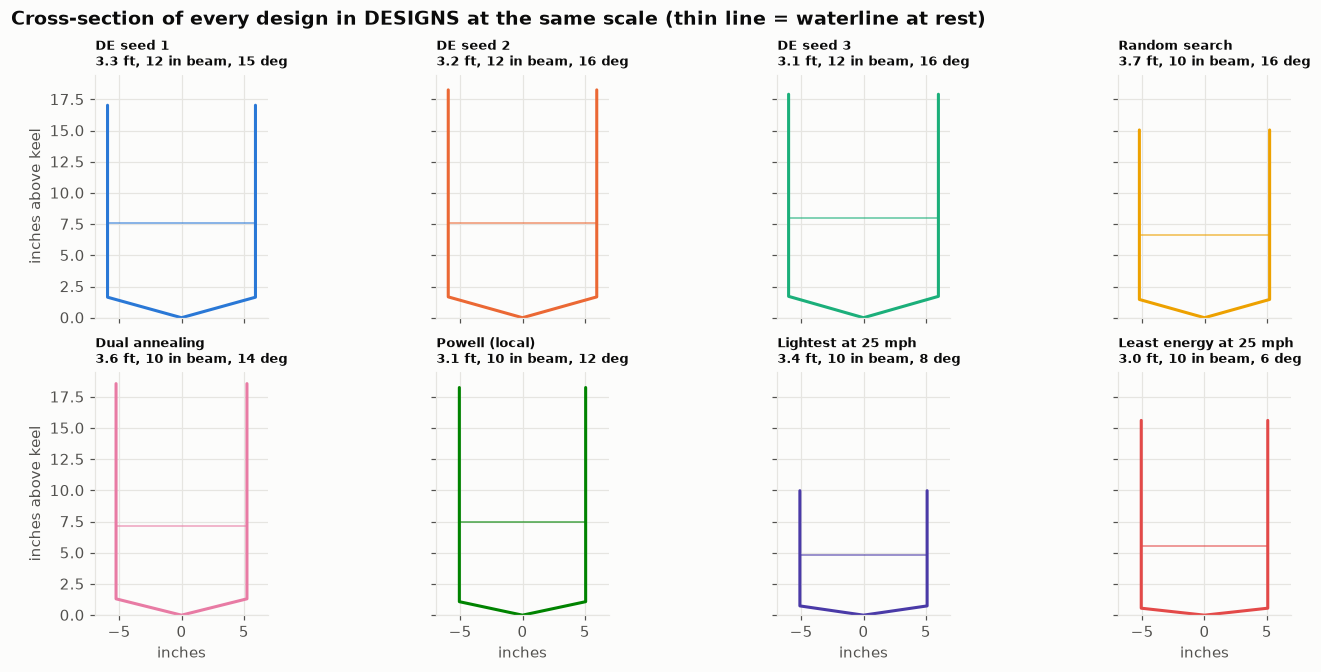

In [103]:
n_ = len(DNAMES); ncols = min(4, n_); nrows = math.ceil(n_ / ncols)
xmax = max(d.beam_in for d, _ in DESIGNS.values()) / 2 * 1.15; ymax = max(d.depth_in for d, _ in DESIGNS.values()) * 1.05
fig, axes = plt.subplots(nrows, ncols, figsize=(3.1 * ncols, 3.0 * nrows), sharex=True, sharey=True, layout="constrained", squeeze=False)
for ax, name in zip(axes.flat, DNAMES):
    d, r = DESIGNS[name]
    b, D, hc = d.beam_in, d.depth_in, chine_height_ft(d) * 12
    ax.plot([-b / 2, -b / 2, 0, b / 2, b / 2], [D, hc, 0, hc, D], color=DCOLOR[name], lw=2)
    ax.hlines(r.m["static_draft_in"], -b / 2, b / 2, color=DCOLOR[name], lw=1, alpha=0.7)
    ax.set_title(f"{name}\n{d.length_ft:.1f} ft, {d.beam_in:.0f} in beam, {d.deadrise_deg:.0f} deg", fontsize=8.5)
    ax.set_aspect("equal"); ax.set_xlim(-xmax, xmax); ax.set_ylim(0, ymax)
for ax in list(axes.flat)[n_:]: ax.axis("off")
for ax in axes[-1]: ax.set_xlabel("inches")
for ax in axes[:, 0]: ax.set_ylabel("inches above keel")
headline(fig, "Cross-section of every design in DESIGNS at the same scale (thin line = waterline at rest)")
plt.show()

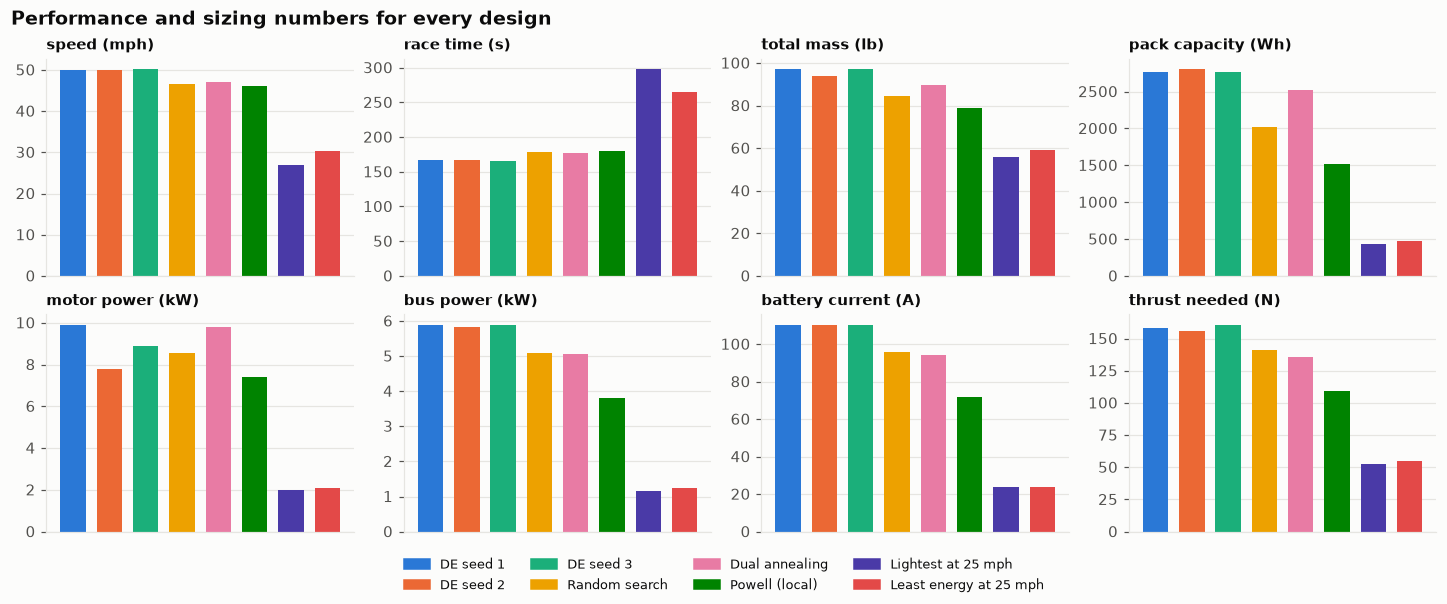

In [104]:
panels = [("speed (mph)", lambda d, r: d.speed_mph), ("race time (s)", lambda d, r: r.m["race_time_s"]), ("total mass (lb)", lambda d, r: r.m["mass_lb"]),
          ("pack capacity (Wh)", lambda d, r: r.m["capacity_wh"]), ("motor power (kW)", lambda d, r: d.motor_kw), ("bus power (kW)", lambda d, r: r.m["bus_w"] / 1000),
          ("battery current (A)", lambda d, r: r.m["current_a"]), ("thrust needed (N)", lambda d, r: r.m["thrust_n"])]
fig, axes = plt.subplots(2, 4, figsize=(13, 5.4), layout="constrained")
for ax, (label, g) in zip(axes.flat, panels):
    vals = [g(*DESIGNS[n]) for n in DNAMES]
    ax.bar(range(len(DNAMES)), vals, color=[DCOLOR[n] for n in DNAMES], width=0.7)
    ax.set_xticks([]); ax.set_title(label, fontsize=9.5); ax.grid(axis="x", visible=False)
fig.legend(handles=[Patch(color=DCOLOR[n], label=n) for n in DNAMES], loc="outside lower center", ncol=4, fontsize=8.5)
headline(fig, "Performance and sizing numbers for every design")
plt.show()

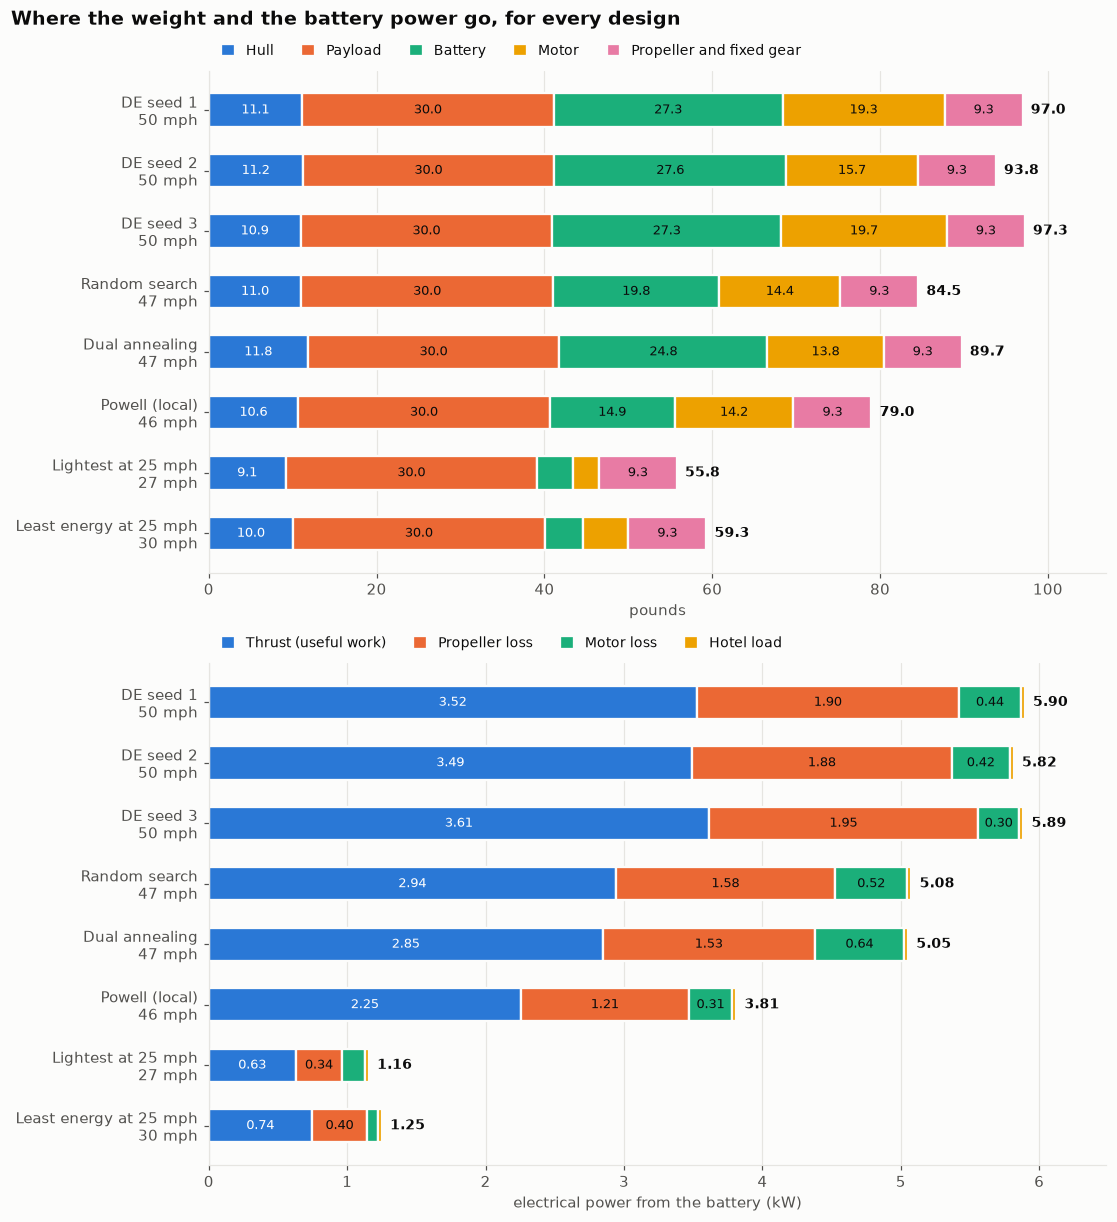

In [105]:
def mass_parts(r):
    m = r.m
    other = m["mass_lb"] - m["hull_lb"] - m["battery_lb"] - m["motor_lb"] - FIXED.payload_lb
    return [("Hull", m["hull_lb"]), ("Payload", FIXED.payload_lb), ("Battery", m["battery_lb"]), ("Motor", m["motor_lb"]), ("Propeller and fixed gear", other)]


def power_parts(d, r):
    m = r.m
    useful = m["thrust_n"] * d.speed_mph * MPH
    return [("Thrust (useful work)", useful / 1000), ("Propeller loss", (m["shaft_w"] - useful) / 1000),
            ("Motor loss", (m["bus_w"] - FIXED.hotel_w - m["shaft_w"]) / 1000), ("Hotel load", FIXED.hotel_w / 1000)]


fig, axes = plt.subplots(2, 1, figsize=(10, 1.1 * len(DNAMES) + 2.2), layout="constrained")
labels = [f"{n}\n{DESIGNS[n][0].speed_mph:.0f} mph" for n in DNAMES]
stacked_hbar(axes[0], labels, [mass_parts(DESIGNS[n][1]) for n in DNAMES]); axes[0].set_xlabel("pounds")
stacked_hbar(axes[1], labels, [power_parts(*DESIGNS[n]) for n in DNAMES], fmt="{:.2f}", min_frac=0.05); axes[1].set_xlabel("electrical power from the battery (kW)")
headline(fig, "Where the weight and the battery power go, for every design")
plt.show()

## Physics against speed

For the designs in `COMPARE`: the planing quantities OpenPlaning returns at each speed, the race time that speed gives, and each
power and energy limit as a share of what it allows. Dots mark where each design's fastest feasible speed falls on the curve.
Change `SPEED_SCAN` to zoom in.

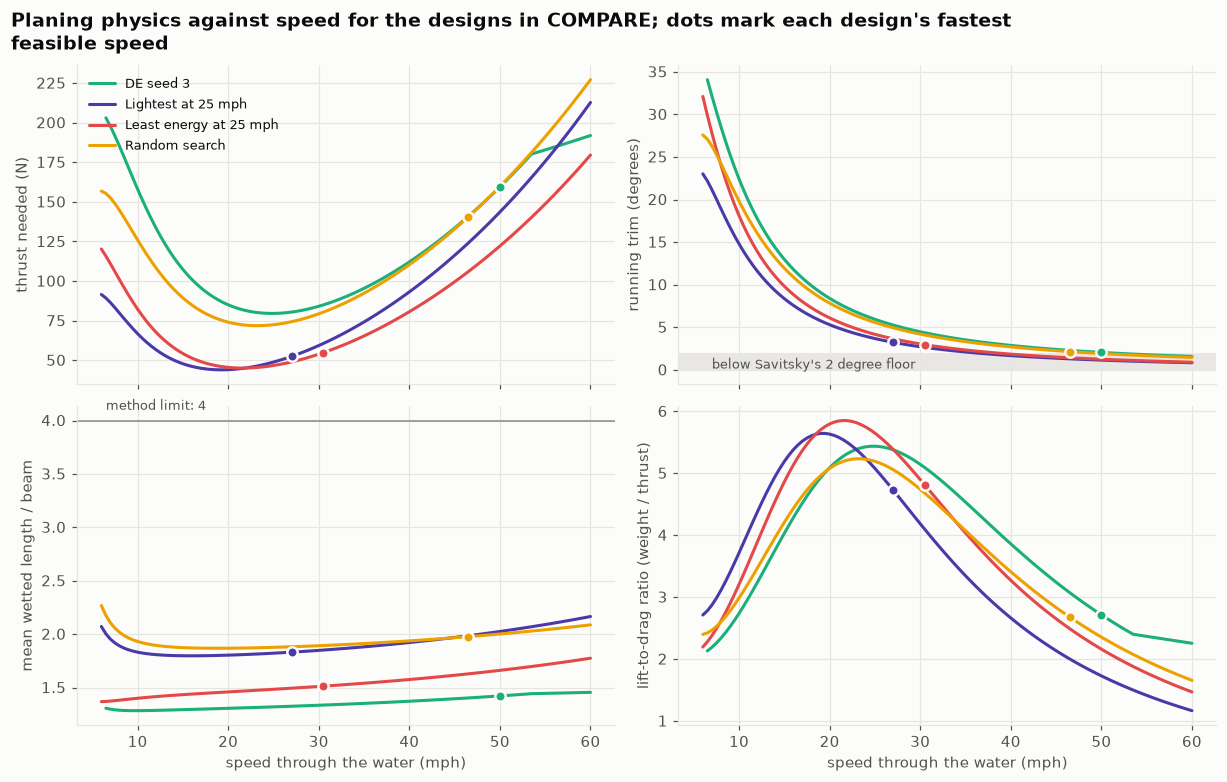

In [106]:
CURVES = {n: scan(DESIGNS[n][0], SPEED_SCAN) for n in COMPARE}
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, layout="constrained")
panels = [("thrust needed (N)", lambda r: r.m["thrust_n"]), ("running trim (degrees)", lambda r: r.m["trim_deg"]),
          ("mean wetted length / beam", lambda r: r.m["planing"]["lam"]), ("lift-to-drag ratio (weight / thrust)", lambda r: r.m["mass_lb"] * LB_N / r.m["thrust_n"])]
for ax, (label, getter) in zip(axes.flat, panels):
    for n in COMPARE:
        y = series(CURVES[n], getter)
        ax.plot(SPEED_SCAN, y, color=DCOLOR[n], label=n)
        k = int(np.argmin(abs(SPEED_SCAN - DESIGNS[n][0].speed_mph)))
        dot(ax, SPEED_SCAN[k], y[k], DCOLOR[n])
    ax.set_ylabel(label)
for ax in axes[1]: ax.set_xlabel("speed through the water (mph)")
ax = axes[0, 1]; ax.axhspan(0, 2, color=GRID, alpha=0.9, lw=0); ax.text(SPEED_SCAN[0] + 1, 0.6, "below Savitsky's 2 degree floor", fontsize=8.5, color=INK2, va="center")
ax = axes[1, 0]; ax.axhline(4, color=MUTED, lw=1); ax.text(SPEED_SCAN[0] + 0.5, 4.1, "method limit: 4", fontsize=8.5, color=INK2)
axes[0, 0].legend(loc="upper left", fontsize=8.5)
headline(fig, "Planing physics against speed for the designs in COMPARE; dots mark each design's fastest feasible speed")
plt.show()

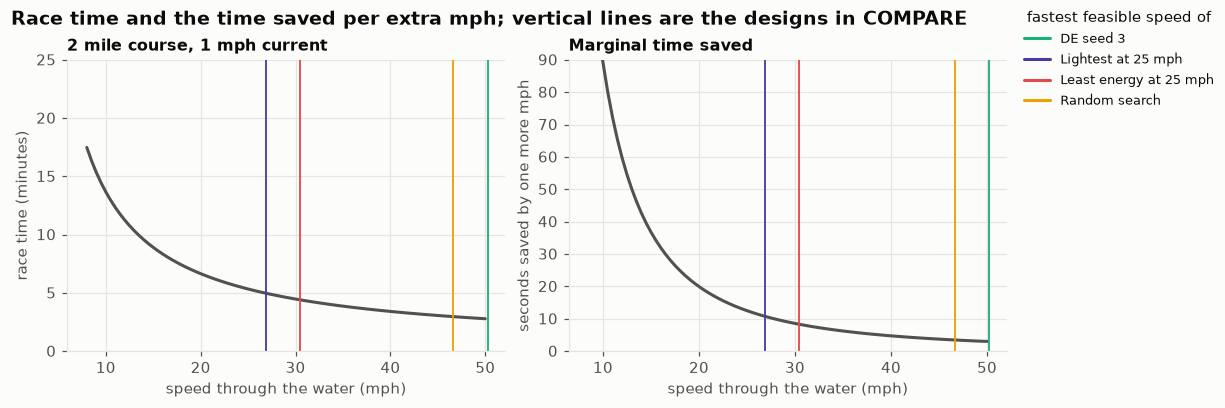

In [107]:
v = np.arange(8, 50.01, 0.5)
minutes = (FIXED.course_miles / (v - FIXED.current_mph) * 3600 + FIXED.allowance_s) / 60
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), layout="constrained")
axes[0].plot(v, minutes, color=INK2); axes[0].set_ylabel("race time (minutes)"); axes[0].set_ylim(0, 25); axes[0].set_title(f"{FIXED.course_miles:g} mile course, {FIXED.current_mph:g} mph current")
axes[1].plot(v[1:], (-np.gradient(minutes, v) * 60)[1:], color=INK2); axes[1].set_ylabel("seconds saved by one more mph"); axes[1].set_ylim(0, 90); axes[1].set_title("Marginal time saved")
for n in COMPARE:
    for ax in axes: ax.axvline(DESIGNS[n][0].speed_mph, color=DCOLOR[n], lw=1.2)
for ax in axes: ax.set_xlabel("speed through the water (mph)")
fig.legend(handles=[plt.Line2D([], [], color=DCOLOR[n], label=n) for n in COMPARE], loc="outside right upper", fontsize=8.5, title="fastest feasible speed of")
headline(fig, "Race time and the time saved per extra mph; vertical lines are the designs in COMPARE")
plt.show()

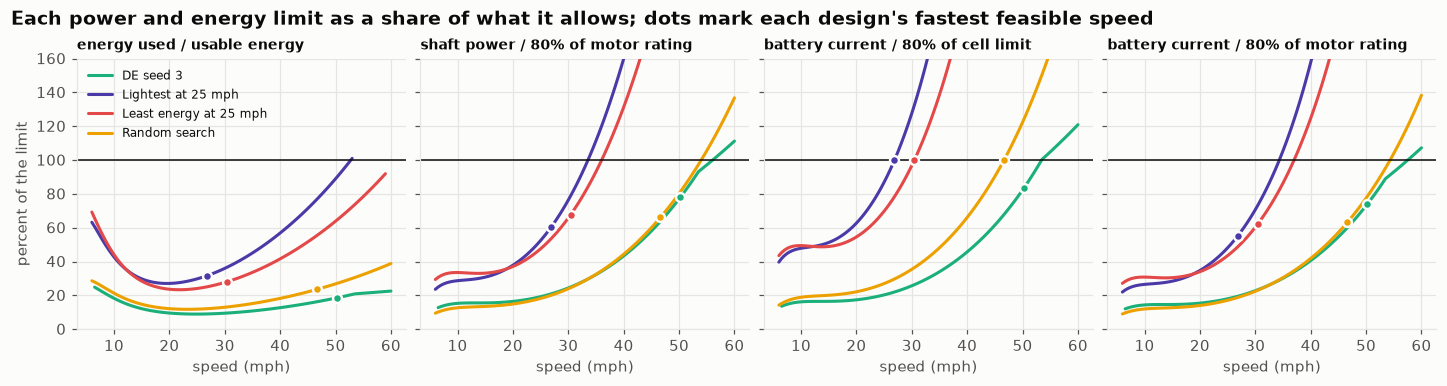

In [108]:
def utilization(d, r):
    # each limit as a share of its allowed value; above 100% the limit is broken
    m, c = r.m, FIXED.cell
    cap_a = FIXED.rating_fraction * d.parallel * c.max_current_a
    motor_a = FIXED.rating_fraction * d.motor_kw * 1000 / (d.motor_eff * d.series * c.v_nominal)
    usable = FIXED.usable_energy_fraction * m["capacity_wh"] * m["start_soc"]
    return dict(energy=100 * m["energy_used_wh"] / usable, shaft=100 * m["shaft_w"] / (FIXED.rating_fraction * d.motor_kw * 1000),
                pack=100 * m["current_a"] / cap_a, motor=100 * m["current_a"] / motor_a)


fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True, layout="constrained")
labels = dict(energy="energy used / usable energy", shaft="shaft power / 80% of motor rating",
              pack="battery current / 80% of cell limit", motor="battery current / 80% of motor rating")
for n in COMPARE:
    d = DESIGNS[n][0]
    u = [utilization(d, r) if r.m["planing"]["ok"] and r.m.get("v_loaded") == r.m.get("v_loaded") else None for r in CURVES[n]]
    for ax, key in zip(axes, labels):
        ax.plot(SPEED_SCAN, [np.nan if x is None else x[key] for x in u], color=DCOLOR[n], label=n)
        dot(ax, d.speed_mph, utilization(d, DESIGNS[n][1])[key], DCOLOR[n], s=34)
for ax, key in zip(axes, labels):
    ax.axhline(100, color=INK, lw=1); ax.set_title(labels[key], fontsize=9); ax.set_xlabel("speed (mph)"); ax.set_ylim(0, 160)
axes[0].set_ylabel("percent of the limit"); axes[0].legend(loc="upper left", fontsize=8)
headline(fig, "Each power and energy limit as a share of what it allows; dots mark each design's fastest feasible speed")
plt.show()

## The battery

How full the pack may start under the voltage rule for 12S to 14S; the pack voltage under load for different parallel counts
(from `V = (Voc + sqrt(Voc^2 - 4 R P)) / 2`); and charge and cell voltage through the race for the `COMPARE` designs.

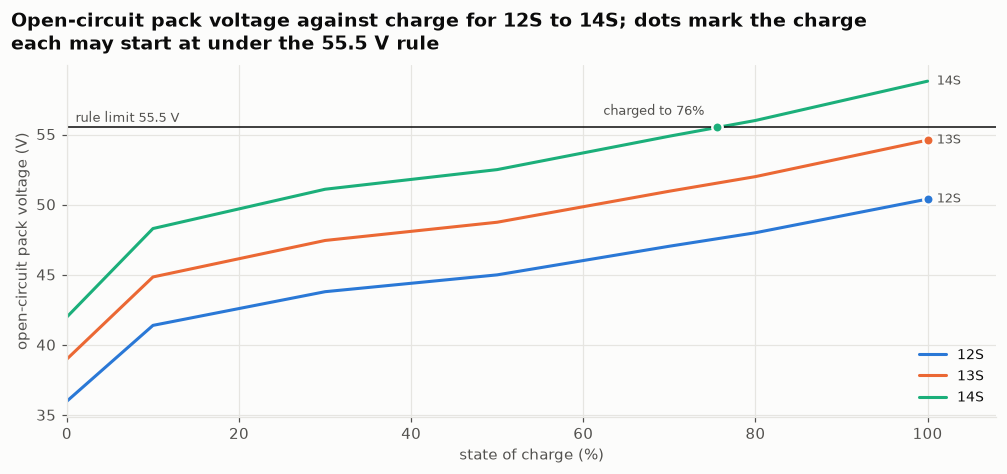

In [109]:
cell = FIXED.cell
soc_grid = np.linspace(0, 1, 101)
fig, ax = plt.subplots(figsize=(9, 4.2), layout="constrained")
for S, color in zip((12, 13, 14), (BLUE, ORANGE, AQUA)):
    volts = S * np.interp(soc_grid, cell.soc, cell.ocv)
    ax.plot(100 * soc_grid, volts, color=color, label=f"{S}S")
    s0 = start_soc(S, FIXED)
    dot(ax, 100 * s0, S * ocv(s0, cell), color)
    end_label(ax, 100, volts[-1], f"{S}S", dx=6)
    if s0 < 1:
        ax.text(100 * s0 - 1.5, S * ocv(s0, cell) + 0.9, f"charged to {100 * s0:.0f}%", ha="right", fontsize=8.5, color=INK2)
ax.axhline(FIXED.voltage_limit_v, color=INK, lw=1)
ax.text(1, FIXED.voltage_limit_v + 0.4, f"rule limit {FIXED.voltage_limit_v} V", fontsize=8.5, color=INK2)
ax.set_xlabel("state of charge (%)"); ax.set_ylabel("open-circuit pack voltage (V)"); ax.set_xlim(0, 108)
ax.legend(loc="lower right")
headline(fig, f"Open-circuit pack voltage against charge for 12S to 14S; dots mark the charge each may start at under the {FIXED.voltage_limit_v} V rule")
plt.show()

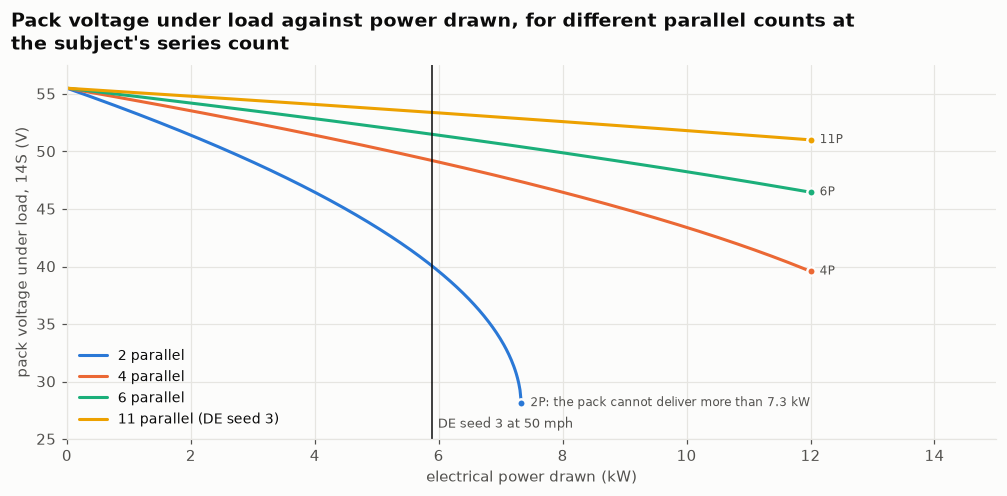

In [110]:
cell = FIXED.cell
S = SUBJ.series
v_oc = S * ocv(start_soc(S, FIXED), cell)
power = np.linspace(0, 12000, 600)
fig, ax = plt.subplots(figsize=(9, 4.4), layout="constrained")
for P, color in zip(sorted({2, 4, 6, SUBJ.parallel}), CAT):
    volts = np.array([loaded_voltage(v_oc, S / P * cell.resistance_ohm, w) for w in power])
    ax.plot(power / 1000, volts, color=color, label=f"{P} parallel" + (f" ({SUBJECT})" if P == SUBJ.parallel else ""))
    k = np.where(np.isfinite(volts))[0][-1]
    dot(ax, power[k] / 1000, volts[k], color, s=30)
    end_label(ax, power[k] / 1000, volts[k], f"{P}P" + (f": the pack cannot deliver more than {power[k] / 1000:.1f} kW" if k < len(power) - 1 else ""), size=8)
bus_kw = SUBJ_R.m["bus_w"] / 1000
ax.axvline(bus_kw, color=INK, lw=1); ax.text(bus_kw + 0.1, 26, f"{SUBJECT} at {SUBJ.speed_mph:.0f} mph", fontsize=8.5, color=INK2, ha="left")
ax.set_xlabel("electrical power drawn (kW)"); ax.set_ylabel(f"pack voltage under load, {S}S (V)")
ax.set_xlim(0, 15); ax.set_ylim(25, v_oc + 2); ax.legend(loc="lower left")
headline(fig, "Pack voltage under load against power drawn, for different parallel counts at the subject's series count")
plt.show()

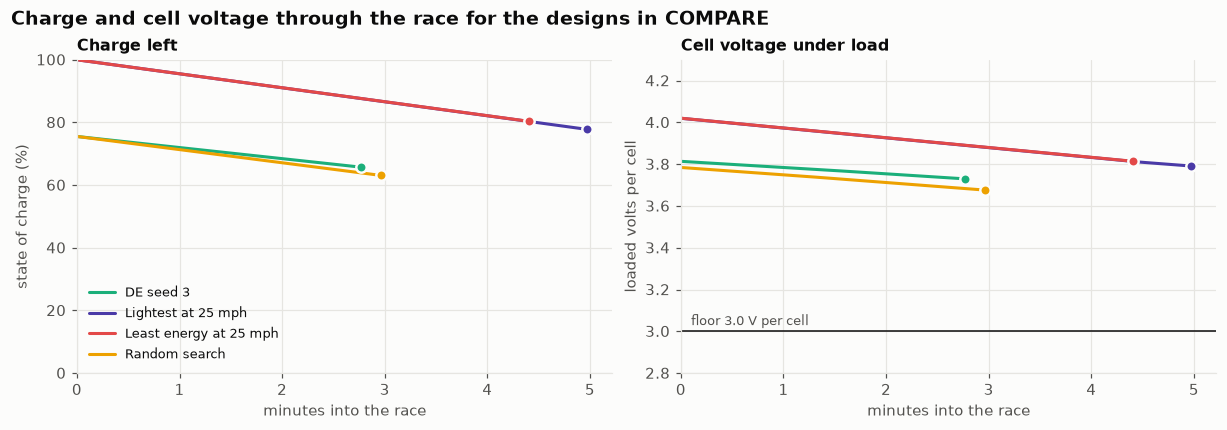

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout="constrained")
for n in COMPARE:
    d, r = DESIGNS[n]; m = r.m; bat = pack(d, FIXED)
    t = np.linspace(0, m["race_time_s"], 120)
    soc = m["start_soc"] - m["bus_w"] * t / 3600 / m["capacity_wh"]
    v_cell = np.array([loaded_voltage(d.series * ocv(max(s, 0.0), FIXED.cell), bat["resistance_ohm"], m["bus_w"]) / d.series for s in soc])
    axes[0].plot(t / 60, 100 * soc, color=DCOLOR[n], label=n); axes[1].plot(t / 60, v_cell, color=DCOLOR[n], label=n)
    dot(axes[0], t[-1] / 60, 100 * soc[-1], DCOLOR[n]); dot(axes[1], t[-1] / 60, v_cell[-1], DCOLOR[n])
axes[0].set_ylabel("state of charge (%)"); axes[0].set_ylim(0, 100); axes[0].set_title("Charge left")
axes[1].axhline(FIXED.min_cell_voltage_end, color=INK, lw=1)
axes[1].text(0.1, FIXED.min_cell_voltage_end + 0.03, f"floor {FIXED.min_cell_voltage_end} V per cell", fontsize=8.5, color=INK2)
axes[1].set_ylabel("loaded volts per cell"); axes[1].set_ylim(2.8, 4.3); axes[1].set_title("Cell voltage under load")
for ax in axes: ax.set_xlabel("minutes into the race"); ax.set_xlim(left=0)
axes[0].legend(loc="lower left", fontsize=8.5)
headline(fig, "Charge and cell voltage through the race for the designs in COMPARE")
plt.show()

## Constraints

A heat map of every constraint's margin across speed for the `SUBJECT`; a map of which constraint binds across a grid of two
variables; and what blocks randomly drawn designs, both those with no feasible speed and those that have one. `SAMPLE_N` sets
how many designs are drawn.

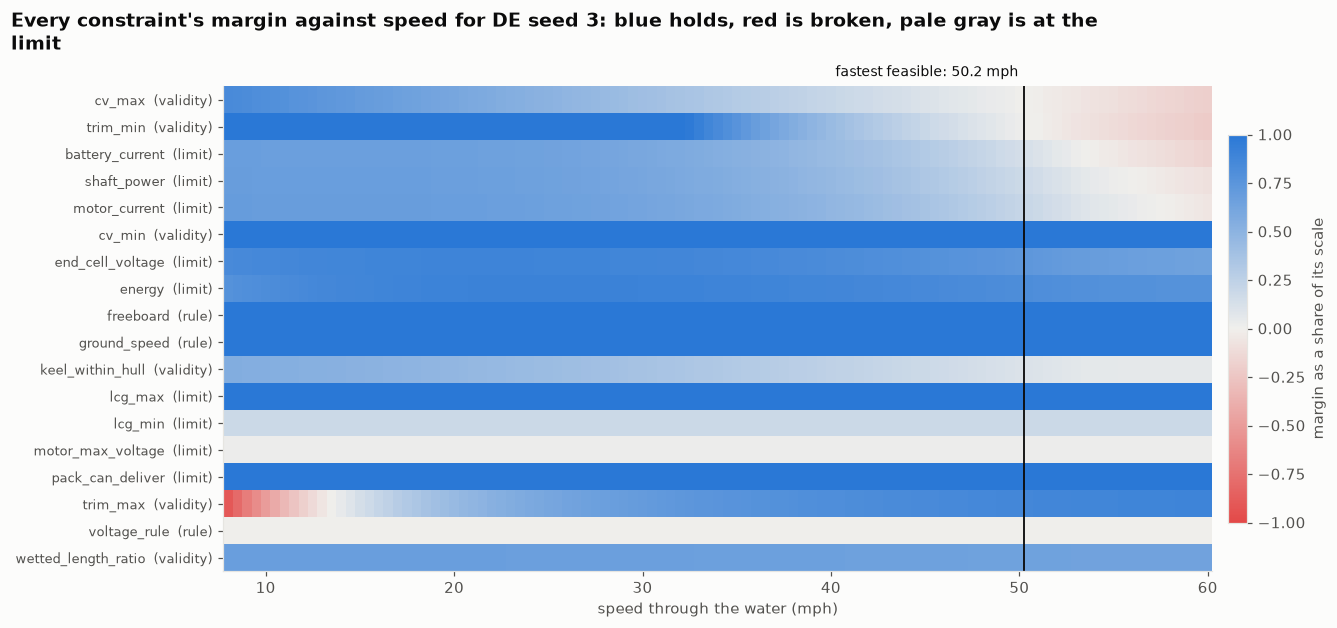

rows are sorted by the speed above the fastest feasible one at which they first fail


In [112]:
sp = np.arange(8, 60.01, 0.5)
rows = [at_speed(SUBJ, s) for s in sp]
widest = max(rows, key=lambda r: len(r.margins))
keys = [k for k in widest.margins if k not in ("solver_ok", "depth_over_chine")]
M = np.clip(np.array([[r.margins[k][0] / r.margins[k][1] if k in r.margins else np.nan for r in rows] for k in keys]), -1, 1)
k0 = int(np.argmin(abs(sp - SUBJ.speed_mph)))
first_fail = [int(k0 + np.argmax(row[k0:] < 0)) if (row[k0:] < 0).any() else 10 ** 6 for row in M]
order = sorted(range(len(keys)), key=lambda i: (first_fail[i], keys[i]))
cmap = DIV.copy(); cmap.set_bad("white")
fig, ax = plt.subplots(figsize=(12, 5.6), layout="constrained")
im = ax.imshow(M[order], aspect="auto", cmap=cmap, vmin=-1, vmax=1, extent=[sp[0] - 0.25, sp[-1] + 0.25, len(keys), 0])
ax.set_yticks(np.arange(len(keys)) + 0.5, [f"{keys[i]}  ({widest.margins[keys[i]][2]})" for i in order], fontsize=8.5)
ax.grid(False); ax.set_xlabel("speed through the water (mph)"); ax.axvline(SUBJ.speed_mph, color=INK, lw=1.2)
ax.text(SUBJ.speed_mph - 0.3, -0.25, f"fastest feasible: {SUBJ.speed_mph:.1f} mph", fontsize=9, va="bottom", ha="right")
fig.colorbar(im, ax=ax, label="margin as a share of its scale", shrink=0.8, pad=0.01)
headline(fig, f"Every constraint's margin against speed for {SUBJECT}: blue holds, red is broken, pale gray is at the limit")
plt.show()
print("rows are sorted by the speed above the fastest feasible one at which they first fail")

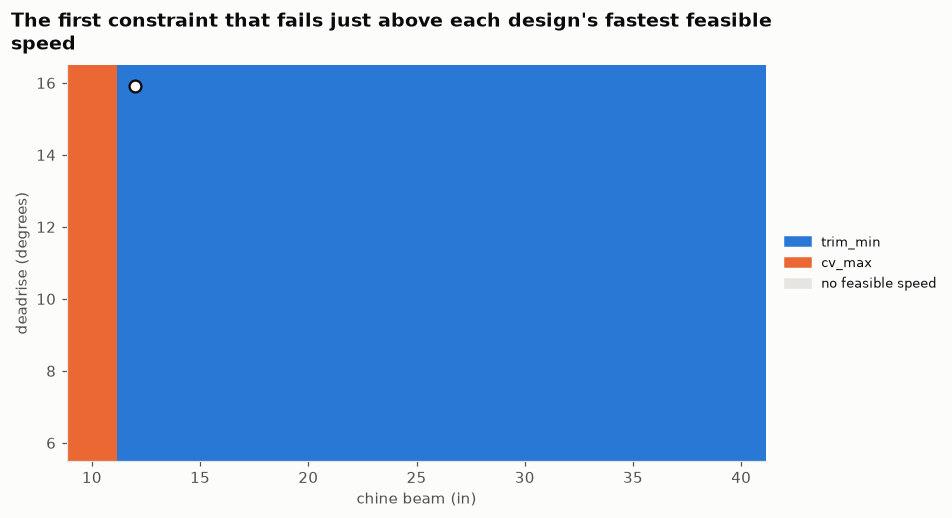

In [113]:
# Which constraint stops the boat, across the first pair of variables in MAP_PAIRS.
xv, xs, xl, yv, ys, yl = MAP_PAIRS[0]
cells_ = {}
for j, y in enumerate(ys):
    for i, x in enumerate(xs):
        dd = replace(SUBJ, **{xv: type(getattr(SUBJ, xv))(x), yv: type(getattr(SUBJ, yv))(y)})
        b = fastest_feasible(dd, FIXED)
        cells_[(j, i)] = "no feasible speed" if b is None else (limiting(replace(dd, speed_mph=b[0]), FIXED)[1] or ["none within 60 mph"])[0]
counts = {}
for c_ in cells_.values(): counts[c_] = counts.get(c_, 0) + 1
classes = [c_ for c_, _ in sorted(counts.items(), key=lambda kv: -kv[1]) if c_ != "no feasible speed"][:7]
color_of = {c_: CAT[i] for i, c_ in enumerate(classes)}
Z = np.full((len(ys), len(xs), 3), mpl.colors.to_rgb(GRID))
for (j, i), c_ in cells_.items():
    Z[j, i] = mpl.colors.to_rgb(color_of.get(c_, MUTED if c_ != "no feasible speed" else GRID))
dx, dy = (xs[1] - xs[0]) / 2, (ys[1] - ys[0]) / 2
fig, ax = plt.subplots(figsize=(8.5, 4.6), layout="constrained")
ax.imshow(Z, origin="lower", aspect="auto", extent=[xs[0] - dx, xs[-1] + dx, ys[0] - dy, ys[-1] + dy]); ax.grid(False)
ax.scatter([getattr(SUBJ, xv)], [getattr(SUBJ, yv)], s=60, color="white", edgecolor=INK, linewidth=1.5, zorder=5)
ax.set_xlabel(xl); ax.set_ylabel(yl)
ax.legend(handles=[Patch(color=color_of[c_], label=c_) for c_ in classes] + [Patch(color=GRID, label="no feasible speed")], loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8.5)
headline(fig, "The first constraint that fails just above each design's fastest feasible speed")
plt.show()

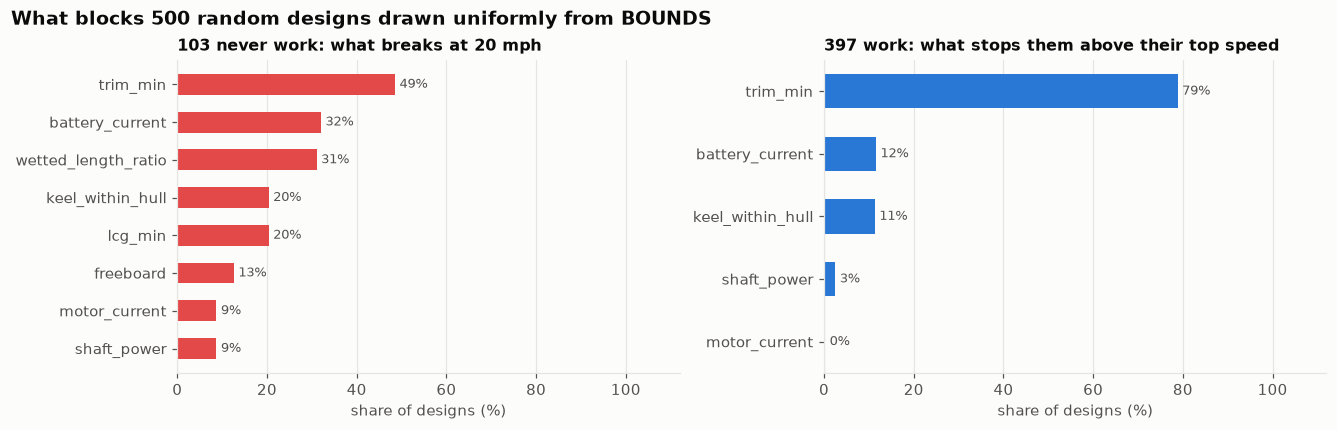

In [114]:
rng = np.random.default_rng(7)
SAMPLE = []
for _ in range(SAMPLE_N):
    d = design_from([rng.uniform(*BOUNDS[n]) for n in NAMES])
    b = fastest_feasible(d, FIXED, step=2.0)
    if b is None:
        SAMPLE.append(dict(d=d, v=None, fail=evaluate(replace(d, speed_mph=20.0), FIXED, 20.0).failing()))
    else:
        v, r = b
        SAMPLE.append(dict(d=d, v=v, r=r, fail=evaluate(replace(d, speed_mph=v + 0.5), FIXED, v + 0.5).failing()))
feasible = [s for s in SAMPLE if s["v"] is not None]
infeasible = [s for s in SAMPLE if s["v"] is None]


def share_bar(ax, groups, total, color, title):
    counts = {}
    for g in groups:
        for k in g: counts[k] = counts.get(k, 0) + 1
    items = sorted(counts.items(), key=lambda kv: kv[1])[-8:]
    ax.barh([k for k, _ in items], [100 * c / total for _, c in items], color=color, height=0.55)
    for i, (_, c) in enumerate(items): ax.text(100 * c / total + 1, i, f"{100 * c / total:.0f}%", va="center", fontsize=8.5, color=INK2)
    ax.set_xlim(0, 112); ax.set_xlabel("share of designs (%)"); ax.set_title(title); ax.grid(axis="y", visible=False)


fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), layout="constrained")
share_bar(axes[0], [s["fail"] for s in infeasible], max(len(infeasible), 1), RED, f"{len(infeasible)} never work: what breaks at 20 mph")
share_bar(axes[1], [s["fail"] for s in feasible], len(feasible), BLUE, f"{len(feasible)} work: what stops them above their top speed")
headline(fig, f"What blocks {len(SAMPLE)} random designs drawn uniformly from BOUNDS")
plt.show()

## Parameters

The `SUBJECT` design with one variable moved to each end of its range; maps over pairs of variables (edit `MAP_PAIRS` for other
pairs, `MAP_METRIC` to color by race time, mass or energy instead of speed); each variable against fastest feasible speed over
the random designs; and the same designs as parallel coordinates.

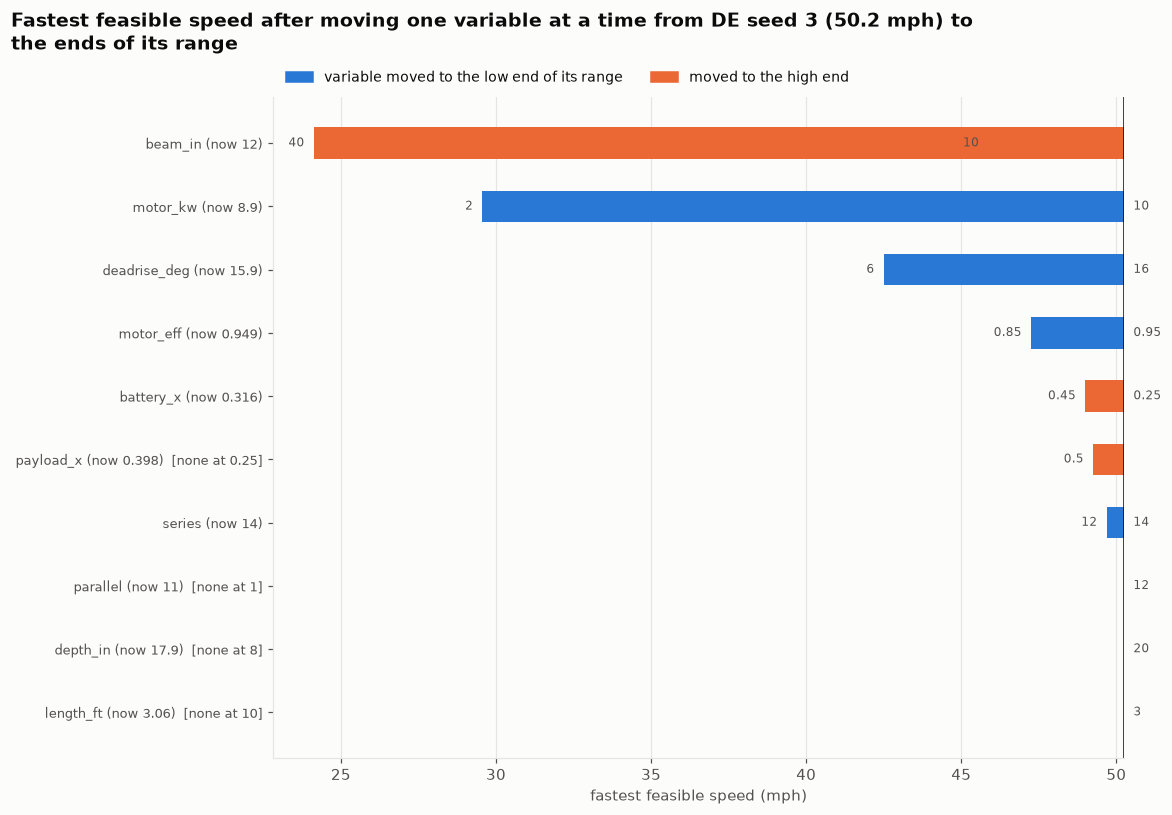

In [115]:
base_speed = SUBJ.speed_mph
rows = []
for n in NAMES:
    lo, hi = BOUNDS[n]
    ends = []
    for x in (lo, hi):
        b = fastest_feasible(replace(SUBJ, **{n: type(getattr(SUBJ, n))(x)}), FIXED)
        ends.append((x, None if b is None else b[0]))
    rows.append((n, ends))
swing = lambda ends: max([abs(v - base_speed) for _, v in ends if v is not None] or [0])
rows.sort(key=lambda r: swing(r[1]))
fig, ax = plt.subplots(figsize=(10.5, 0.55 * len(rows) + 1.8), layout="constrained")
for i, (n, ends) in enumerate(rows):
    for (x, v), color in zip(ends, (BLUE, ORANGE)):
        if v is None: continue
        ax.barh(i, v - base_speed, left=base_speed, height=0.5, color=color)
        ax.text(v + (0.3 if v >= base_speed else -0.3), i, f"{x:g}", ha="left" if v >= base_speed else "right", va="center", fontsize=8, color=INK2)
ax.set_yticks(range(len(rows)), [f"{n} (now {getattr(SUBJ, n):.3g})" + "".join(f"  [none at {x:g}]" for x, v in ends if v is None) for n, ends in rows], fontsize=8.5)
ax.axvline(base_speed, color=INK, lw=1); ax.grid(axis="y", visible=False); ax.set_xlabel("fastest feasible speed (mph)")
ax.legend(handles=[Patch(color=BLUE, label="variable moved to the low end of its range"), Patch(color=ORANGE, label="moved to the high end")], ncol=2, loc="lower left", bbox_to_anchor=(0, 1.0))
headline(fig, f"Fastest feasible speed after moving one variable at a time from {SUBJECT} ({base_speed:.1f} mph) to the ends of its range")
plt.show()

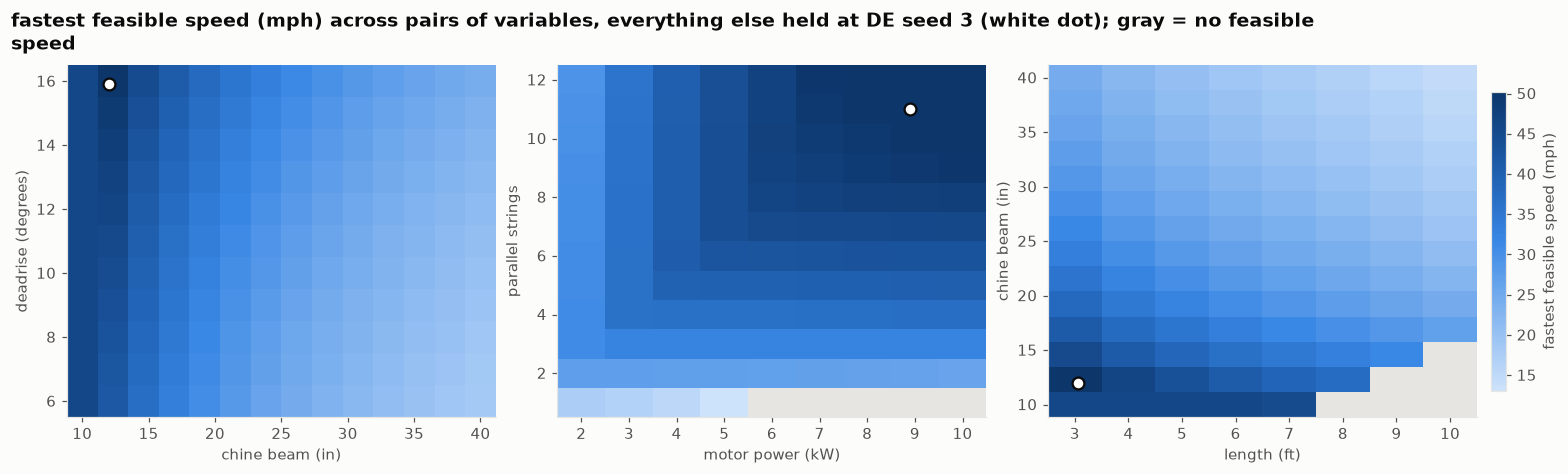

In [116]:
def grid_map(xvar, xs, yvar, ys, metric, base):
    Z = np.full((len(ys), len(xs)), np.nan)
    for j, y in enumerate(ys):
        for i, x in enumerate(xs):
            b = fastest_feasible(replace(base, **{xvar: type(getattr(base, xvar))(x), yvar: type(getattr(base, yvar))(y)}), FIXED)
            if b: Z[j, i] = metric(*b)
    return Z


MAPS = [grid_map(xv, xs, yv, ys, MAP_METRICS[MAP_METRIC], SUBJ) for xv, xs, _, yv, ys, _ in MAP_PAIRS]
vmax, vmin = np.nanmax([np.nanmax(Z) for Z in MAPS]), np.nanmin([np.nanmin(Z) for Z in MAPS])
cm = SEQ.copy(); cm.set_bad(GRID)
fig, axes = plt.subplots(1, len(MAP_PAIRS), figsize=(4.7 * len(MAP_PAIRS), 4.2), layout="constrained")
for ax, Z, (xv, xs, xl, yv, ys, yl) in zip(np.atleast_1d(axes), MAPS, MAP_PAIRS):
    dx, dy = (xs[1] - xs[0]) / 2, (ys[1] - ys[0]) / 2
    im = ax.imshow(Z, origin="lower", aspect="auto", cmap=cm, vmin=vmin, vmax=vmax, extent=[xs[0] - dx, xs[-1] + dx, ys[0] - dy, ys[-1] + dy])
    ax.grid(False); ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.scatter([getattr(SUBJ, xv)], [getattr(SUBJ, yv)], s=60, color="white", edgecolor=INK, linewidth=1.5, zorder=5)
fig.colorbar(im, ax=axes, label=MAP_METRIC, shrink=0.85, pad=0.01)
headline(fig, f"{MAP_METRIC} across pairs of variables, everything else held at {SUBJECT} (white dot); gray = no feasible speed")
plt.show()

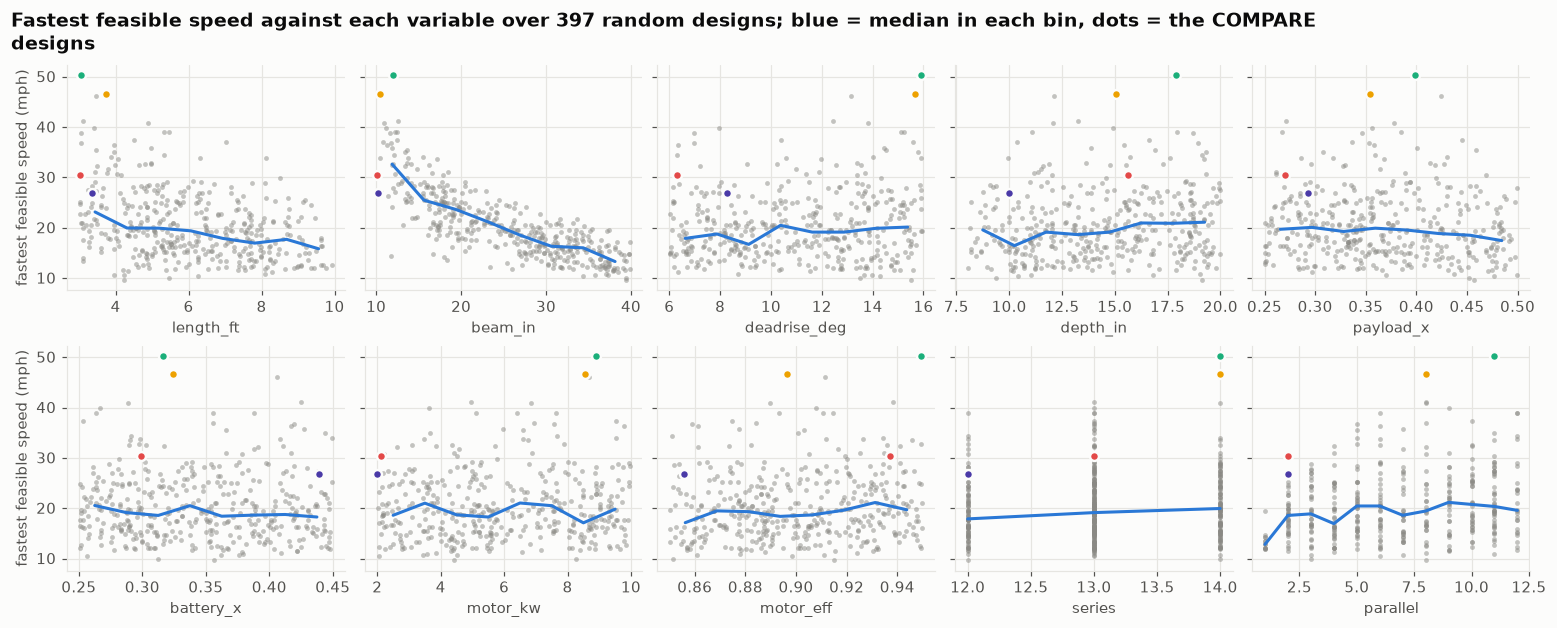

In [117]:
fig, axes = plt.subplots(2, 5, figsize=(14, 5.6), sharey=True, layout="constrained")
for ax, n in zip(axes.flat, NAMES):
    xs = np.array([getattr(s_["d"], n) for s_ in feasible]); ys = np.array([s_["v"] for s_ in feasible])
    ax.scatter(xs, ys, s=10, color=MUTED, alpha=0.5, linewidth=0)
    edges = np.linspace(*BOUNDS[n], 9) if n not in INTEGER else np.arange(BOUNDS[n][0] - 0.5, BOUNDS[n][1] + 1.5)
    mid, med = [], []
    for lo_, hi_ in zip(edges[:-1], edges[1:]):
        sel = (xs >= lo_) & (xs < hi_)
        if sel.sum() >= 3: mid.append((lo_ + hi_) / 2); med.append(np.median(ys[sel]))
    ax.plot(mid, med, color=BLUE, lw=2)
    for name in COMPARE: dot(ax, getattr(DESIGNS[name][0], n), DESIGNS[name][0].speed_mph, DCOLOR[name], s=34)
    ax.set_xlabel(n)
for ax in axes[:, 0]: ax.set_ylabel("fastest feasible speed (mph)")
headline(fig, f"Fastest feasible speed against each variable over {len(feasible)} random designs; blue = median in each bin, dots = the COMPARE designs")
plt.show()

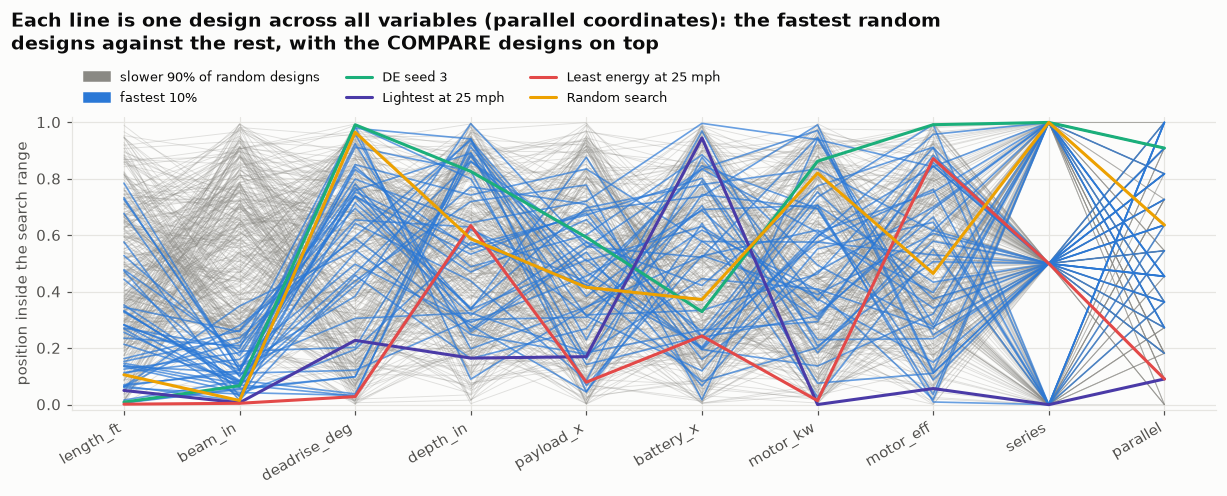

In [118]:
norm = lambda d: [(getattr(d, n) - BOUNDS[n][0]) / (BOUNDS[n][1] - BOUNDS[n][0]) for n in NAMES]
vs = np.array([s_["v"] for s_ in feasible]); cut = np.quantile(vs, 0.9)
fig, ax = plt.subplots(figsize=(11, 4.4), layout="constrained")
for s_ in feasible:
    if s_["v"] < cut: ax.plot(range(len(NAMES)), norm(s_["d"]), color=MUTED, lw=0.6, alpha=0.25)
for s_ in feasible:
    if s_["v"] >= cut: ax.plot(range(len(NAMES)), norm(s_["d"]), color=BLUE, lw=1.1, alpha=0.7)
for name in COMPARE: ax.plot(range(len(NAMES)), norm(DESIGNS[name][0]), color=DCOLOR[name], lw=2, label=name)
ax.set_xticks(range(len(NAMES)), NAMES, rotation=30, ha="right"); ax.set_ylabel("position inside the search range"); ax.set_ylim(-0.02, 1.02)
ax.legend(handles=[Patch(color=MUTED, label="slower 90% of random designs"), Patch(color=BLUE, label="fastest 10%")] + [plt.Line2D([], [], color=DCOLOR[n], label=n) for n in COMPARE],
          loc="lower left", bbox_to_anchor=(0, 1.0), ncol=3, fontsize=8.5)
headline(fig, "Each line is one design across all variables (parallel coordinates): the fastest random designs against the rest, with the COMPARE designs on top")
plt.show()

## Assumptions

Each assumption in `Fixed` (marked `PLACEHOLDER` in Part I) varied alone, for the `COMPARE` designs, then ranked by how much speed
changes across the range tried. Edit `ASSUMPTIONS` to sweep others; `cell.` reaches the battery cell. A flat line means that
assumption does not change *this* answer, which can be because another constraint binds first.

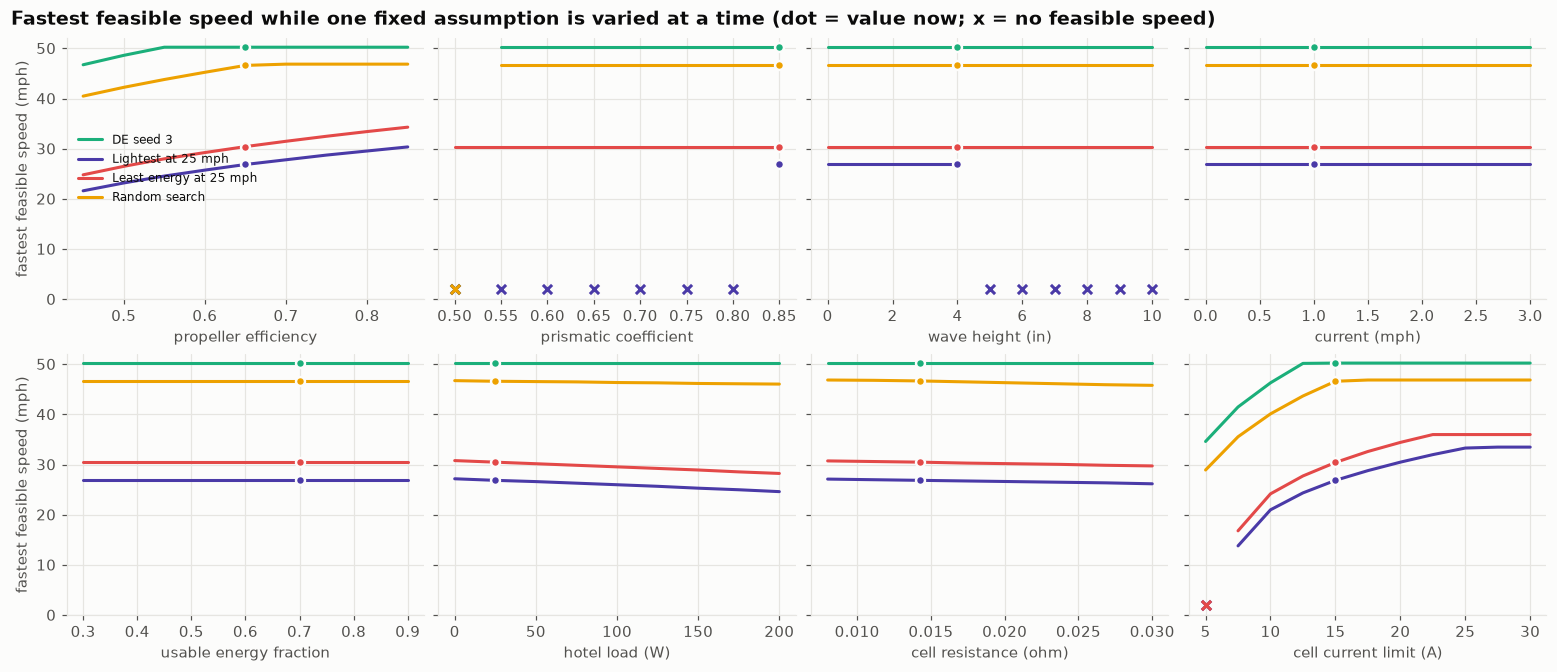

In [119]:
# Edit this list to sweep other assumptions; the path "cell.x" reaches inside Fixed.cell.
ASSUMPTIONS = [("prop_efficiency", np.linspace(0.45, 0.85, 9), "propeller efficiency"), ("prismatic_coeff", np.linspace(0.5, 0.85, 8), "prismatic coefficient"),
               ("wave_height_in", np.linspace(0, 10, 11), "wave height (in)"), ("current_mph", np.linspace(0, 3, 7), "current (mph)"),
               ("usable_energy_fraction", np.linspace(0.3, 0.9, 7), "usable energy fraction"), ("hotel_w", np.linspace(0, 200, 9), "hotel load (W)"),
               ("cell.resistance_ohm", np.linspace(0.008, 0.03, 8), "cell resistance (ohm)"), ("cell.max_current_a", np.linspace(5, 30, 11), "cell current limit (A)")]
ncols = 4; nrows = math.ceil(len(ASSUMPTIONS) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.0 * nrows), sharey=True, layout="constrained", squeeze=False)
swings = {}
for ax, (path, vals, label) in zip(axes.flat, ASSUMPTIONS):
    for n in COMPARE:
        d = DESIGNS[n][0]
        ys = np.array([np.nan if (b := fastest_feasible(d, with_fixed(FIXED, path, float(x)))) is None else b[0] for x in vals])
        ax.plot(vals, ys, color=DCOLOR[n], label=n)
        bad = np.isnan(ys)
        if bad.any(): ax.scatter(vals[bad], np.full(bad.sum(), 2.0), marker="x", s=36, color=DCOLOR[n], zorder=5)
        swings.setdefault(n, {})[label] = (float(np.max(np.nan_to_num(ys)) - np.min(np.nan_to_num(ys))), int(bad.sum()), len(vals))
        cur = FIXED.cell.__dict__[path[5:]] if path.startswith("cell.") else getattr(FIXED, path)
        k = int(np.argmin(abs(vals - cur)))
        if not bad[k]: dot(ax, vals[k], ys[k], DCOLOR[n], s=34)
    ax.set_xlabel(label)
for ax in axes[:, 0]: ax.set_ylabel("fastest feasible speed (mph)")
axes[0, 0].set_ylim(0, 52); axes[0, 0].legend(loc="center left", fontsize=8)
for ax in list(axes.flat)[len(ASSUMPTIONS):]: ax.axis("off")
headline(fig, "Fastest feasible speed while one fixed assumption is varied at a time (dot = value now; x = no feasible speed)")
plt.show()

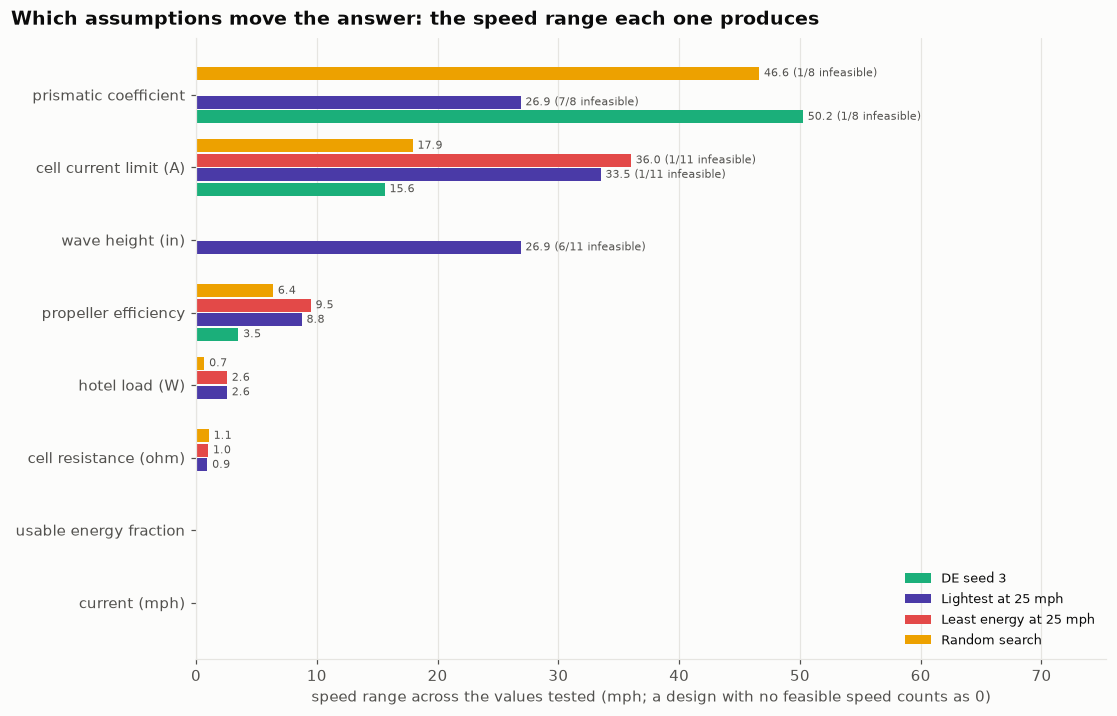

In [120]:
labels = [a[2] for a in ASSUMPTIONS]
order = sorted(labels, key=lambda l: max(swings[n][l][0] for n in COMPARE))
nb = len(COMPARE); h = 0.8 / nb
fig, ax = plt.subplots(figsize=(10, 0.55 * len(labels) + 2), layout="constrained")
for j, n in enumerate(COMPARE):
    for i, l in enumerate(order):
        sw, nbad, nvals = swings[n][l]
        y = i + (j - (nb - 1) / 2) * h
        ax.barh(y, sw, height=h * 0.9, color=DCOLOR[n], label=n if i == 0 else None)
        if sw > 0.05 or nbad: ax.text(0.4 + sw, y, f"{sw:.1f}" + (f" ({nbad}/{nvals} infeasible)" if nbad else ""), va="center", fontsize=7.5, color=INK2)
ax.set_yticks(range(len(order)), order); ax.grid(axis="y", visible=False)
ax.set_xlim(0, max(10, 1.5 * max(swings[n][l][0] for n in COMPARE for l in labels)))
ax.set_xlabel("speed range across the values tested (mph; a design with no feasible speed counts as 0)"); ax.legend(loc="lower right", fontsize=8.5)
headline(fig, "Which assumptions move the answer: the speed range each one produces")
plt.show()

## What-ifs

The `SUBJECT` with some fields overridden: the plan's 34 in beam hull, less deadrise, payload moved aft. Edit `WHAT_IFS` to try
your own. A curve ends where OpenPlaning finds no balance.

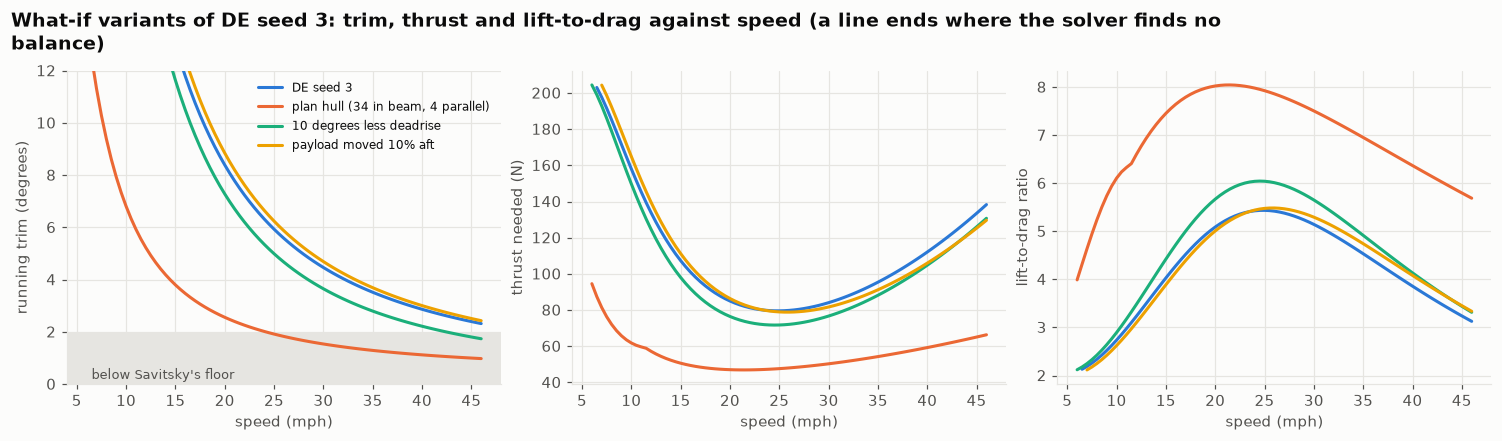

In [121]:
# Variants of the subject design. Each entry overrides some Design fields.
WHAT_IFS = {"plan hull (34 in beam, 4 parallel)": dict(beam_in=34.0, parallel=4),
            "10 degrees less deadrise": dict(deadrise_deg=max(SUBJ.deadrise_deg - 10, 2)),
            "payload moved 10% aft": dict(payload_x=SUBJ.payload_x - 0.10)}
variants = {SUBJECT: SUBJ, **{k: replace(SUBJ, **kw) for k, kw in WHAT_IFS.items()}}
colors_ = {k: CAT[i] for i, k in enumerate(variants)}
spd = np.arange(6, 46.01, 0.5)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9), sharex=True, layout="constrained")
for k, d in variants.items():
    rs = scan(d, spd)
    for ax, g in zip(axes, (lambda r: r.m["trim_deg"], lambda r: r.m["thrust_n"], lambda r: r.m["mass_lb"] * LB_N / r.m["thrust_n"])):
        ax.plot(spd, series(rs, g), color=colors_[k], label=k)
axes[0].axhspan(0, 2, color=GRID, lw=0); axes[0].set_ylim(0, 12); axes[0].text(6.5, 0.35, "below Savitsky's floor", fontsize=8.5, color=INK2, va="center")
axes[0].set_ylabel("running trim (degrees)"); axes[1].set_ylabel("thrust needed (N)"); axes[2].set_ylabel("lift-to-drag ratio")
for ax in axes: ax.set_xlabel("speed (mph)")
axes[0].legend(loc="upper right", fontsize=8)
headline(fig, f"What-if variants of {SUBJECT}: trim, thrust and lift-to-drag against speed (a line ends where the solver finds no balance)")
plt.show()

## 17. What to replace next

- **Cell data** (`Cell`): use a real datasheet, especially resistance, continuous current and the voltage-versus-charge curve.
- **Motor mass fit** (`motor_mass_lb`) and **motor max voltage**: fit to real products.
- **Propeller efficiency** (`prop_efficiency`): needs a model. Until then pitch and diameter only change rpm, tip speed and Kv.
- **Prismatic coefficient** (`prismatic_coeff`): sets static buoyancy and therefore freeboard.
- **Wave height and current** (`wave_height_in`, `current_mph`): set from the race venue.
- **Placement heights and gyradius**: from the real layout.
- **Deferred hull variables** (transom beam, bow deadrise, keel curve) are not in this notebook; OpenPlaning cannot use them.